In [39]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4_entropictest3있음중요함!!/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-graddetach5_joint_lrdown/42/best_vanilla.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.1_kl_gamma-2.0_tau-0.2_target_data-heart_entropic_reg-0.01_description-None/50/20251224_141356/best.pt"
ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.1_kl_gamma-2.0_tau-0.2_target_data-heart_entropic_reg-0.01_description-None/50/20251225_051316/best.pt"
# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph(
    (q_proj): Linear(in_features=768, out_features=192, bias=True)
    (k_proj): Linear(in_features=768, out_features=192, bias=True)
  )
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_laye

In [40]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


>>> [System] Seed 50 FIXED. Deterministic algorithms ENABLED.
Loading dataloader for source: Medicaldataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Medicaldataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 791
Validation data size: 264
Test data size: 264
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 162
Validation data s

In [41]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings


In [42]:
import matplotlib.pyplot as plt
import numpy as np
import os
def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()





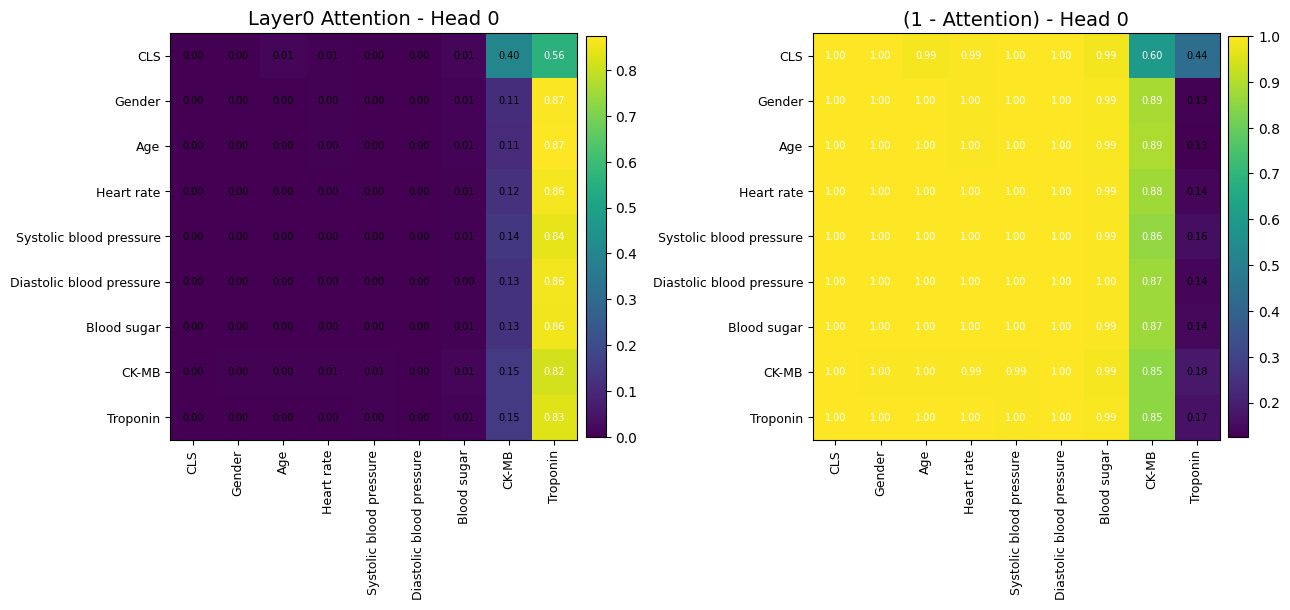

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=0.0132 | std=0.1290
         Gender  | mean=0.0557 | std=2.3972
            Age  | mean=0.0294 | std=0.6801
     Heart rate  | mean=0.2717 | std=6.3218
Systolic blood pressure  | mean=-0.0604 | std=1.6766
Diastolic blood pressure  | mean=-0.2164 | std=5.3662
    Blood sugar  | mean=-0.0504 | std=1.5446
          CK-MB  | mean=-0.1597 | std=3.4902
       Troponin  | mean=-0.1543 | std=3.4640

=== Global embedding statistics ===
global mean: -0.0301
global std : 3.4081


In [43]:
src = sources[0]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)



### Affinity Two sample

In [44]:
import numpy as np
from collections import defaultdict
@torch.no_grad()
def collect_all_samples_from_source(model, loader, source_name):
    """
    한 source의 모든 샘플에 대해 node embedding과 affinity 추출
    
    Returns:
        all_embeddings: list of [N, D] arrays (CLS 제외한 variable nodes만)
        all_affinities: list of [N, N] arrays (1 - attention, Var-Var만)
        all_labels: list of labels
        all_feature_names: list of feature name lists
    """
    all_embeddings = []
    all_affinities = []
    all_labels = []
    all_feature_names = []
    
    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        # desc/name/value gather
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        
        B = value.size(0)

        # CLS + value token concat
        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

        last_att = None
        
        # each BasisGAT layer
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)
            
            # attention shape: [B, H, T, T]
            last_att = att
            
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        # last_att: [B, H, T, T]
        # Head 0 사용
        last_att = last_att[:, 0, :, :]  # [B, T, T]
        
        # Feature names
        var_names = extract_feature_names(batch)
        
        for b in range(B):
            # CLS 제외 (1:부터)
            node_emb = x_basis[b, 1:, :].detach().cpu().numpy()  # [N, D]
            
            # Var-Var attention만 (CLS 제외)
            var_att = last_att[b, 1:, 1:].detach().cpu().numpy()  # [N, N]
            
            # 1 - attention = distance/affinity
            affinity = 1.0 - var_att
            
            all_embeddings.append(node_emb)
            all_affinities.append(affinity)
            all_labels.append(batch['y'][b].item())
            all_feature_names.append(var_names)
    
    return all_embeddings, all_affinities, all_labels, all_feature_names

def compute_frobenius_distances(embeddings, affinities):
    """
    모든 샘플 쌍의 Frobenius distance 계산
    
    Returns:
        emb_distances: [n_samples, n_samples] embedding Frobenius distances
        aff_distances: [n_samples, n_samples] affinity Frobenius distances
    """
    n = len(embeddings)
    emb_distances = np.zeros((n, n))
    aff_distances = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            # Embedding Frobenius distance
            emb_diff = np.linalg.norm(embeddings[i] - embeddings[j], ord='fro')
            emb_distances[i, j] = emb_diff
            emb_distances[j, i] = emb_diff
            
            # Affinity Frobenius distance
            aff_diff = np.linalg.norm(affinities[i] - affinities[j], ord='fro')
            aff_distances[i, j] = aff_diff
            aff_distances[j, i] = aff_diff
    
    return emb_distances, aff_distances

def find_most_similar_and_different_by_label(reference_idx, distances, labels):
    """
    Reference 샘플과 같은/다른 레이블 내에서 가장 유사/상이한 샘플 찾기
    
    Returns:
        most_similar_same_label_idx: 같은 레이블 중 가장 유사
        most_different_other_label_idx: 다른 레이블 중 가장 상이
    """
    n = len(distances)
    ref_label = labels[reference_idx]
    
    # 같은 레이블 샘플들
    same_label_mask = np.array([labels[i] == ref_label for i in range(n)])
    same_label_mask[reference_idx] = False  # 자기자신 제외
    
    # 다른 레이블 샘플들
    other_label_mask = np.array([labels[i] != ref_label for i in range(n)])
    
    # 같은 레이블 중 가장 유사 (거리 최소)
    dist_same_label = distances[reference_idx].copy()
    dist_same_label[~same_label_mask] = np.inf
    most_similar_same_label_idx = np.argmin(dist_same_label)
    
    # 다른 레이블 중 가장 상이 (거리 최대)
    dist_other_label = distances[reference_idx].copy()
    dist_other_label[~other_label_mask] = -np.inf
    most_different_other_label_idx = np.argmax(dist_other_label)
    
    return most_similar_same_label_idx, most_different_other_label_idx

In [45]:
# 1. 데이터 수집
src = sources[1]  # 첫 번째 source
loader = loaders[src]

print(f"Collecting samples from source: {src}")
embeddings, affinities, labels, feature_names_list = collect_all_samples_from_source(model, loader, src)

print(f"Total samples collected: {len(embeddings)}")
print(f"Node embedding shape: {embeddings[0].shape}")
print(f"Affinity shape: {affinities[0].shape}")

Total samples collected: 1000
Node embedding shape: (13, 768)
Affinity shape: (13, 13)


In [46]:
# 2. Frobenius distance 계산
print("Computing Frobenius distances...")
emb_distances, aff_distances = compute_frobenius_distances(embeddings, affinities)

print(f"Embedding distance matrix shape: {emb_distances.shape}")
print(f"Affinity distance matrix shape: {aff_distances.shape}")

Computing Frobenius distances...
Embedding distance matrix shape: (1000, 1000)
Affinity distance matrix shape: (1000, 1000)


In [47]:
# 3. Reference 샘플 선택 (예: 첫 번째 샘플)
reference_idx = 0

# Affinity 기준으로 같은 레이블에서 가장 유사, 다른 레이블에서 가장 상이한 샘플 찾기
similar_idx, different_idx = find_most_similar_and_different_by_label(reference_idx, aff_distances, labels)

print(f"\n=== Analysis based on Affinity Frobenius Distance (Label-aware) ===")
print(f"Reference sample: {reference_idx} (label: {labels[reference_idx]})")
print(f"\nMost similar (SAME label): {similar_idx} (label: {labels[similar_idx]})")
print(f"  → Affinity Frobenius distance: {aff_distances[reference_idx, similar_idx]:.4f}")
print(f"\nMost different (OTHER label): {different_idx} (label: {labels[different_idx]})")
print(f"  → Affinity Frobenius distance: {aff_distances[reference_idx, different_idx]:.4f}")


=== Analysis based on Affinity Frobenius Distance (Label-aware) ===
Reference sample: 0 (label: 1)

Most similar (SAME label): 389 (label: 1)
  → Affinity Frobenius distance: 0.1160

Most different (OTHER label): 697 (label: 0)
  → Affinity Frobenius distance: 1.2996



=== Reference Sample Affinity ===


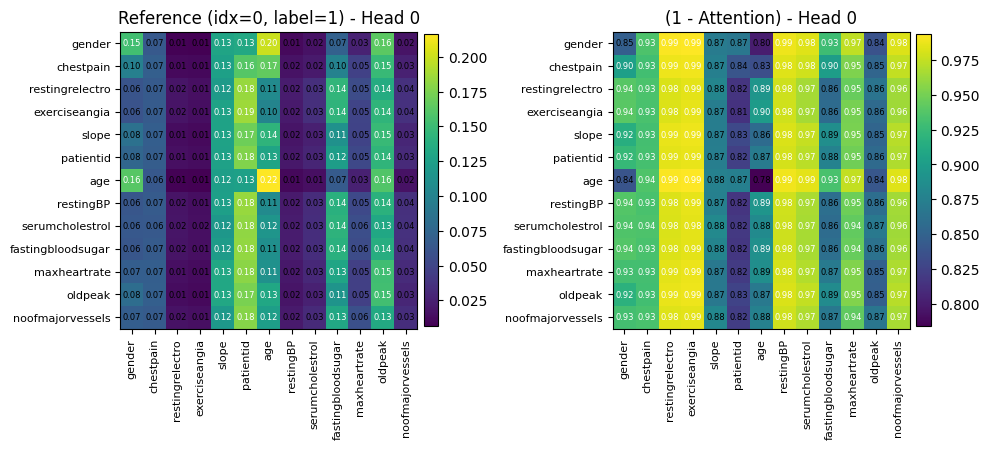


=== Most Similar Sample (SAME Label) Affinity ===
Frobenius distance: 0.1160


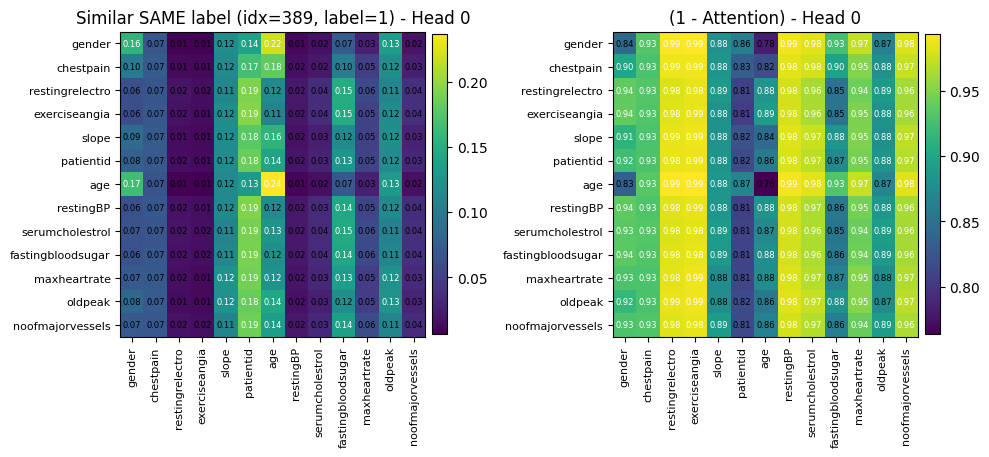


=== Most Different Sample (OTHER Label) Affinity ===
Frobenius distance: 1.2996


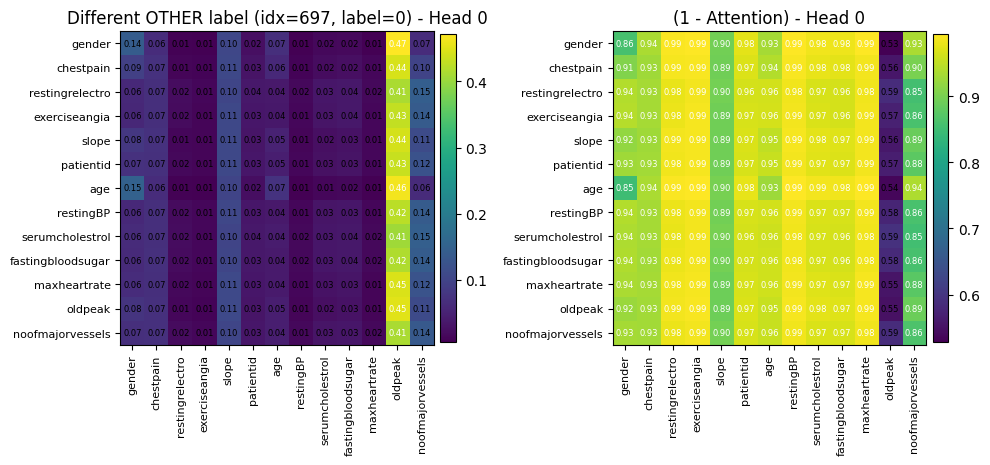

In [48]:
# 4. 시각화
feature_names = ["CLS"] + feature_names_list[0]
var_names = feature_names_list[0]

# Reference 샘플 affinity
ref_aff = affinities[reference_idx]
# Most similar (same label) 샘플 affinity
sim_aff = affinities[similar_idx]
# Most different (other label) 샘플 affinity
diff_aff = affinities[different_idx]

# 3D attention shape로 변환 (plot 함수 호환)
ref_aff_3d = ref_aff[np.newaxis, :, :]  # [1, N, N]
sim_aff_3d = sim_aff[np.newaxis, :, :]
diff_aff_3d = diff_aff[np.newaxis, :, :]

print("\n=== Reference Sample Affinity ===")
plot_attention_with_inverse(
    att=1.0 - ref_aff_3d,  # affinity를 다시 attention으로
    feature_names=var_names,
    title=f"Reference (idx={reference_idx}, label={labels[reference_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

print("\n=== Most Similar Sample (SAME Label) Affinity ===")
print(f"Frobenius distance: {aff_distances[reference_idx, similar_idx]:.4f}")
plot_attention_with_inverse(
    att=1.0 - sim_aff_3d,
    feature_names=var_names,
    title=f"Similar SAME label (idx={similar_idx}, label={labels[similar_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

print("\n=== Most Different Sample (OTHER Label) Affinity ===")
print(f"Frobenius distance: {aff_distances[reference_idx, different_idx]:.4f}")
plot_attention_with_inverse(
    att=1.0 - diff_aff_3d,
    feature_names=var_names,
    title=f"Different OTHER label (idx={different_idx}, label={labels[different_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

In [49]:
# Joint 모델 로드
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4_entropictest3있음중요함!!/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-entropictest3/42/best.pt"
#joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.1_kl_gamma-2.0_tau-0.2_target_data-heart_entropic_reg-0.01_description-None/50/20251224_141356/best_joint.pt"
joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.1_kl_gamma-2.0_tau-0.2_target_data-heart_entropic_reg-0.01_description-None/50/20251225_051316/best_joint.pt"
joint_ckpt_pretrain = torch.load(joint_ckpt_pretrain_path, map_location=device)
joint_args = joint_ckpt_pretrain['args']

# Joint 모델 초기화
joint_model_pretrain = Model(
    joint_args,
    joint_args.input_dim,
    joint_args.hidden_dim,
    joint_args.output_dim,
    joint_args.dropout_rate,
    joint_args.llm_model,
    experiment_id="joint_viz",
    mode="Full"
).to(device)

joint_sd = joint_ckpt_pretrain['model_state_dict']
missing, unexpected = joint_model_pretrain.load_state_dict(joint_sd, strict=False)
print("Joint Model Loaded")
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

joint_model_pretrain.eval()

Joint Model Loaded
Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph(
    (q_proj): Linear(in_features=768, out_features=192, bias=True)
    (k_proj): Linear(in_features=768, out_features=192, bias=True)
  )
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_laye

In [50]:
@torch.no_grad()
def compute_transport_plans_for_samples(model, sample_indices, embeddings, affinities):
    """
    3개 샘플 (ref, similar, different) x 8개 LCG = 24개 Transport Plan 계산
    
    Args:
        model: Joint trained model
        sample_indices: [ref_idx, similar_idx, different_idx]
        embeddings: list of node embeddings
        affinities: list of affinity matrices
    
    Returns:
        plans: [3, 8, N, K] Transport Plans
        distances: [3, 8] FGW distances
        coordinates: [3, 8] Soft assignments (pi)
    """
    # LCG 가져오기
    lcg_feat, lcg_struct = model.latent_graph()  # [M, K, D], [M, K, K]
    M, K, D = lcg_feat.shape
    
    n_samples = len(sample_indices)
    
    # 결과 저장
    all_plans = []
    all_distances = []
    all_coordinates = []
    
    for idx in sample_indices:
        # Source 준비
        src_feat = torch.from_numpy(embeddings[idx]).float().to(device).unsqueeze(0)  # [1, N, D]
        src_str = torch.from_numpy(affinities[idx]).float().to(device).unsqueeze(0)   # [1, N, N]
        
        N = src_feat.shape[1]
        
        # Expand for M LCGs
        src_feat_exp = src_feat.unsqueeze(1).expand(1, M, N, D).reshape(M, N, D)  # [M, N, D]
        src_str_exp = src_str.unsqueeze(1).expand(1, M, N, N).reshape(M, N, N)    # [M, N, N]
        
        # LCG 준비
        lcg_feat_exp = lcg_feat  # [M, K, D]
        lcg_str_exp = lcg_struct  # [M, K, K]
        
        # FGW 계산 (GraphQuantizer의 compute_fgw 재현)
        dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
        tau = model.graph_quantizer.tau
        M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))
        
        a = torch.ones(M, N, device=device) / N
        b = torch.ones(M, K, device=device) / K
        
        alpha = model.graph_quantizer.alpha
        reg = model.graph_quantizer.reg
        
        # Solve FGW
        result = solve_gromov_batch(
            src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )
        
        distances = result.value.detach().cpu().numpy()  # [M]
        plans = result.plan.detach().cpu().numpy()       # [M, N, K]
        
        # Soft assignment (pi)
        soft_tau = model.graph_quantizer.soft_tau
        pi = torch.softmax(-result.value / soft_tau, dim=0).detach().cpu().numpy()  # [M]
        
        all_plans.append(plans)
        all_distances.append(distances)
        all_coordinates.append(pi)
    
    all_plans = np.array(all_plans)           # [3, M, N, K]
    all_distances = np.array(all_distances)   # [3, M]
    all_coordinates = np.array(all_coordinates)  # [3, M]
    
    return all_plans, all_distances, all_coordinates

In [51]:
def plot_transport_plans_grid(plans, coordinates, distances, sample_indices, labels, var_names):
    """
    3 x 8 Grid로 Transport Plan 시각화
    + 각 LCG별로 Reference vs Similar, Reference vs Different의 Frobenius norm 표시
    
    Args:
        plans: [3, 8, N, K]
        coordinates: [3, 8] (pi values)
        distances: [3, 8] (FGW distances)
        sample_indices: [ref_idx, similar_idx, different_idx]
        labels: list of all labels
        var_names: list of variable names
    """
    n_samples = 3
    n_lcgs = 8
    
    fig, axes = plt.subplots(n_samples, n_lcgs, figsize=(24, 9))
    
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
    
    # 각 LCG별 Frobenius norm 계산
    frob_norms_similar = []  # Reference vs Similar
    frob_norms_different = []  # Reference vs Different
    
    for j in range(n_lcgs):
        plan_ref = plans[0, j]      # Reference
        plan_sim = plans[1, j]      # Similar
        plan_diff = plans[2, j]     # Different
        
        frob_ref_sim = np.linalg.norm(plan_ref - plan_sim, ord='fro')
        frob_ref_diff = np.linalg.norm(plan_ref - plan_diff, ord='fro')
        
        frob_norms_similar.append(frob_ref_sim)
        frob_norms_different.append(frob_ref_diff)
    
    for i in range(n_samples):
        for j in range(n_lcgs):
            ax = axes[i, j]
            
            plan = plans[i, j]  # [N, K]
            pi = coordinates[i, j]
            dist = distances[i, j]
            
            # Heatmap
            im = ax.imshow(plan, cmap='viridis', aspect='auto')
            
            # Title
            if i == 0:
                ax.set_title(f'LCG {j}\nπ={pi:.3f}\nD={dist:.3f}', fontsize=10)
            else:
                ax.set_title(f'π={pi:.3f}\nD={dist:.3f}', fontsize=9)
            
            # Y-axis (Source variables)
            if j == 0:
                ax.set_ylabel(f'{sample_names[i]}\n(idx={sample_indices[i]}, label={labels[sample_indices[i]]})', 
                             fontsize=9)
                ax.set_yticks(range(len(var_names)))
                ax.set_yticklabels(var_names, fontsize=7)
            else:
                ax.set_yticks([])
            
            # X-axis (LCG nodes)
            if i == n_samples - 1:
                ax.set_xlabel(f'LCG Nodes (K={plan.shape[1]})', fontsize=8)
                ax.set_xticks(range(plan.shape[1]))
                ax.set_xticklabels(range(plan.shape[1]), fontsize=7)
            else:
                ax.set_xticks([])
            
            # Frobenius norm 표시 (Different row의 맨 아래)
            if i == n_samples - 1:
                frob_sim = frob_norms_similar[j]
                frob_diff = frob_norms_different[j]
                
                # X-axis label 아래에 Frobenius norm 추가
                ax.text(0.5, -0.25, f'Frob: Sim={frob_sim:.3f} vs Diff={frob_diff:.3f}',
                       transform=ax.transAxes,
                       ha='center', va='top',
                       fontsize=8, color='red',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
            
            # Colorbar
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)  # Frobenius norm 텍스트 공간 확보
    plt.suptitle('Transport Plans: Reference vs Similar vs Different (across 8 LCGs)', 
                 fontsize=14, y=0.99)
    plt.show()

In [52]:
# 실행
print("Computing Transport Plans for 3 samples x 8 LCGs...")
sample_indices = [reference_idx, similar_idx, different_idx]

plans, distances, coordinates = compute_transport_plans_for_samples(
    joint_model_pretrain, sample_indices, embeddings, affinities
)

print(f"Plans shape: {plans.shape}")  # [3, 8, N, K]
print(f"Distances shape: {distances.shape}")  # [3, 8]
print(f"Coordinates shape: {coordinates.shape}")  # [3, 8]

print("\n=== Coordinates (pi) ===")
print("Reference:", coordinates[0])
print("Similar:", coordinates[1])
print("Different:", coordinates[2])

print("\n=== FGW Distances ===")
print("Reference:", distances[0])
print("Similar:", distances[1])
print("Different:", distances[2])

Computing Transport Plans for 3 samples x 8 LCGs...
Plans shape: (3, 8, 13, 8)
Distances shape: (3, 8)
Coordinates shape: (3, 8)

=== Coordinates (pi) ===
Reference: [0.15868874 0.07215866 0.08079884 0.09617531 0.14558855 0.10499435
 0.19340369 0.1481919 ]
Similar: [0.16390836 0.07130853 0.0830627  0.09031164 0.1420311  0.10345703
 0.18570621 0.16021447]
Different: [0.13951689 0.08865637 0.0988582  0.07900447 0.14014754 0.14447382
 0.16000451 0.14933822]

=== FGW Distances ===
Reference: [0.308215   0.34761888 0.3419641  0.3332536  0.312523   0.3288669
 0.29832324 0.31163684]
Similar: [0.32118937 0.36280397 0.35517496 0.35099143 0.32835245 0.34419695
 0.31494647 0.3223291 ]
Different: [0.29879305 0.32146394 0.31601802 0.32722712 0.29856756 0.29704744
 0.29194224 0.29539165]


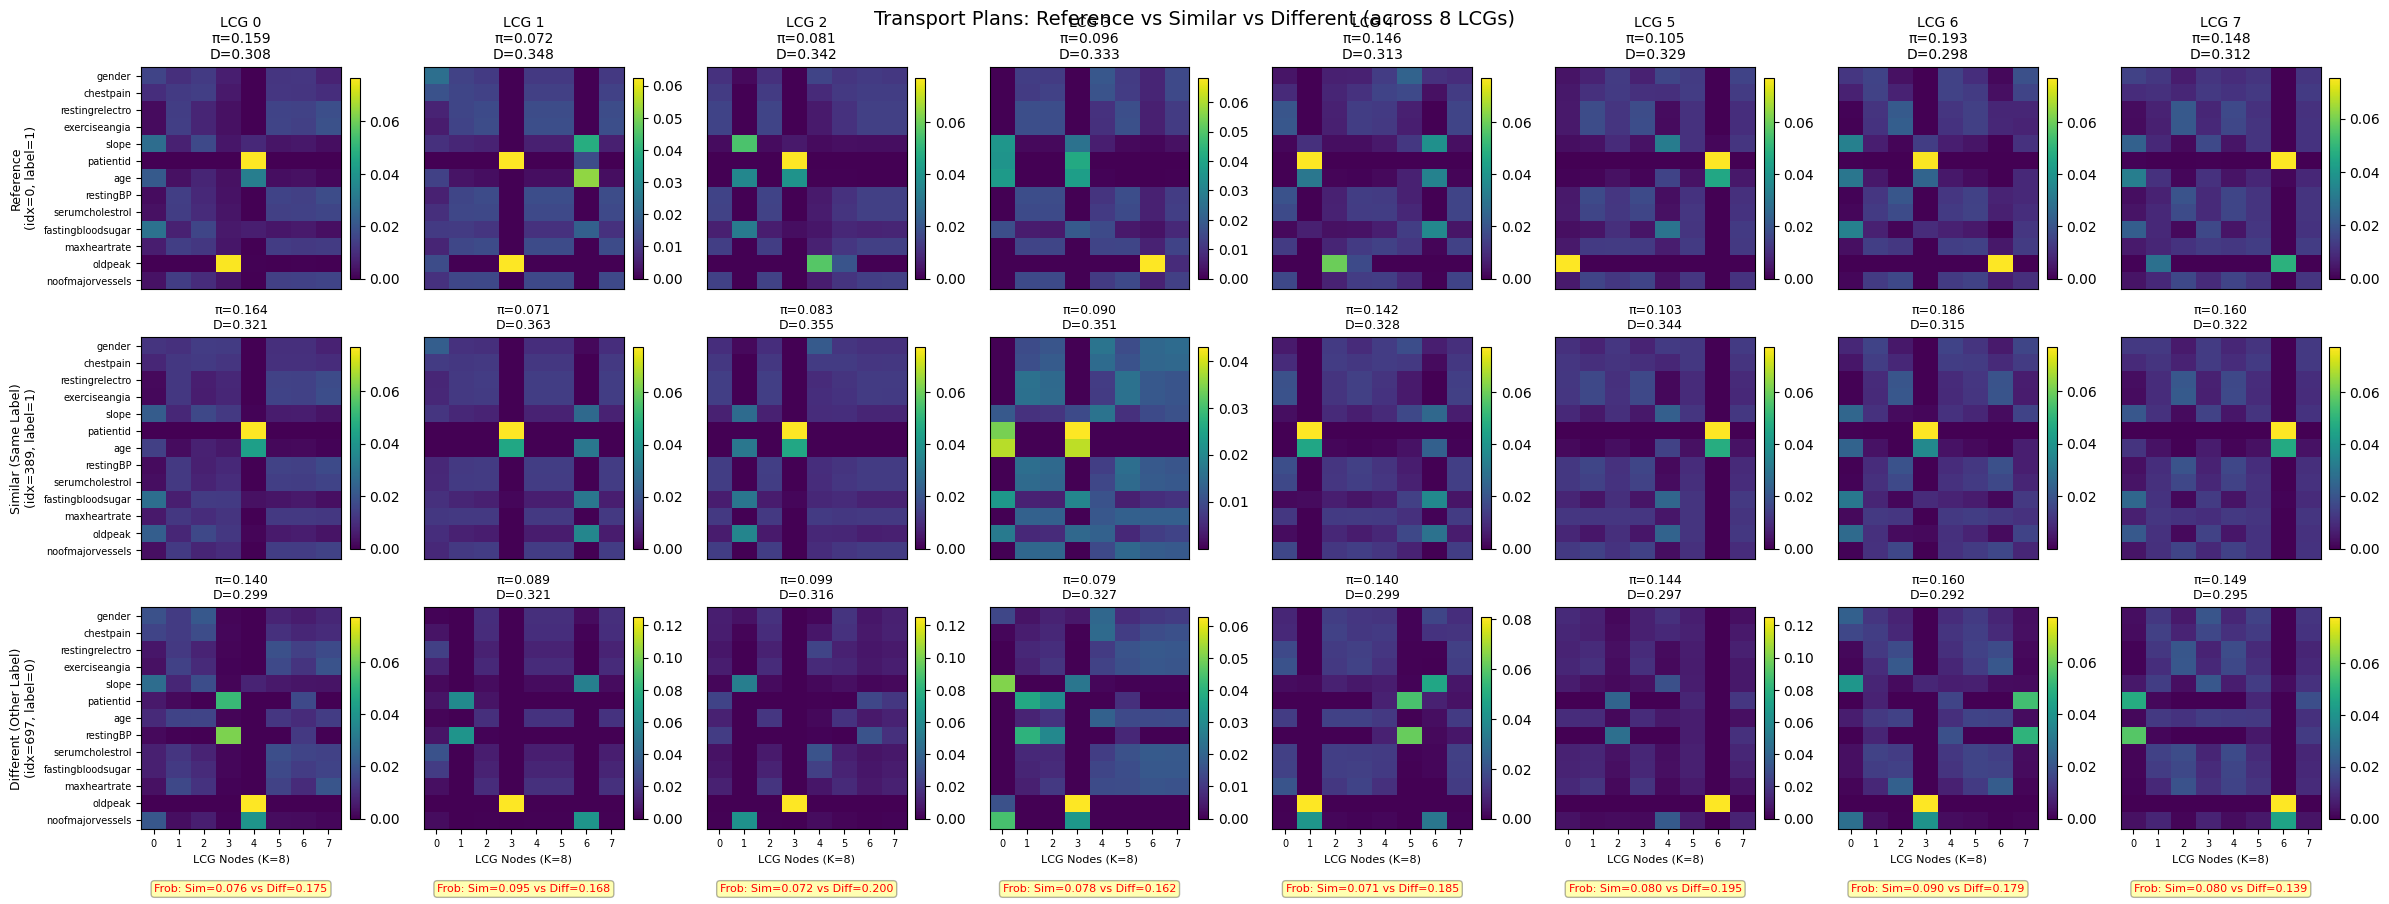

In [53]:
# 시각화
plot_transport_plans_grid(
    plans, coordinates, distances, 
    sample_indices, labels, var_names
)

In [54]:
# Pi (coordinates) 출력
print("=== Pi (Soft Assignment Probabilities) ===")
print("\nReference sample (idx={}, label={}):".format(reference_idx, labels[reference_idx]))
print(coordinates[0])
print(f"Sum: {coordinates[0].sum():.6f}")
print(f"Max: {coordinates[0].max():.4f}, Min: {coordinates[0].min():.4f}")
print(f"Std: {coordinates[0].std():.6f}")

print("\nSimilar sample (idx={}, label={}):".format(similar_idx, labels[similar_idx]))
print(coordinates[1])
print(f"Sum: {coordinates[1].sum():.6f}")
print(f"Max: {coordinates[1].max():.4f}, Min: {coordinates[1].min():.4f}")
print(f"Std: {coordinates[1].std():.6f}")

print("\nDifferent sample (idx={}, label={}):".format(different_idx, labels[different_idx]))
print(coordinates[2])
print(f"Sum: {coordinates[2].sum():.6f}")
print(f"Max: {coordinates[2].max():.4f}, Min: {coordinates[2].min():.4f}")
print(f"Std: {coordinates[2].std():.6f}")

print("\n=== Pi Comparison ===")
print("Reference vs Similar - Frobenius: {:.6f}".format(
    np.linalg.norm(coordinates[0] - coordinates[1])
))
print("Reference vs Different - Frobenius: {:.6f}".format(
    np.linalg.norm(coordinates[0] - coordinates[2])
))

# Raw distances (softmax 전)
print("\n=== Raw FGW Distances (before softmax) ===")
print("Reference:", distances[0])
print("Similar:", distances[1])
print("Different:", distances[2])

print("\n=== Distance Comparison ===")
print("Reference vs Similar - Frobenius: {:.6f}".format(
    np.linalg.norm(distances[0] - distances[1])
))
print("Reference vs Different - Frobenius: {:.6f}".format(
    np.linalg.norm(distances[0] - distances[2])
))

=== Pi (Soft Assignment Probabilities) ===

Reference sample (idx=0, label=1):
[0.15868874 0.07215866 0.08079884 0.09617531 0.14558855 0.10499435
 0.19340369 0.1481919 ]
Sum: 1.000000
Max: 0.1934, Min: 0.0722
Std: 0.039926

Similar sample (idx=389, label=1):
[0.16390836 0.07130853 0.0830627  0.09031164 0.1420311  0.10345703
 0.18570621 0.16021447]
Sum: 1.000000
Max: 0.1857, Min: 0.0713
Std: 0.040370

Different sample (idx=697, label=0):
[0.13951689 0.08865637 0.0988582  0.07900447 0.14014754 0.14447382
 0.16000451 0.14933822]
Sum: 1.000000
Max: 0.1600, Min: 0.0790
Std: 0.029062

=== Pi Comparison ===
Reference vs Similar - Frobenius: 0.016920
Reference vs Different - Frobenius: 0.062974

=== Raw FGW Distances (before softmax) ===
Reference: [0.308215   0.34761888 0.3419641  0.3332536  0.312523   0.3288669
 0.29832324 0.31163684]
Similar: [0.32118937 0.36280397 0.35517496 0.35099143 0.32835245 0.34419695
 0.31494647 0.3223291 ]
Different: [0.29879305 0.32146394 0.31601802 0.32722712 0.2

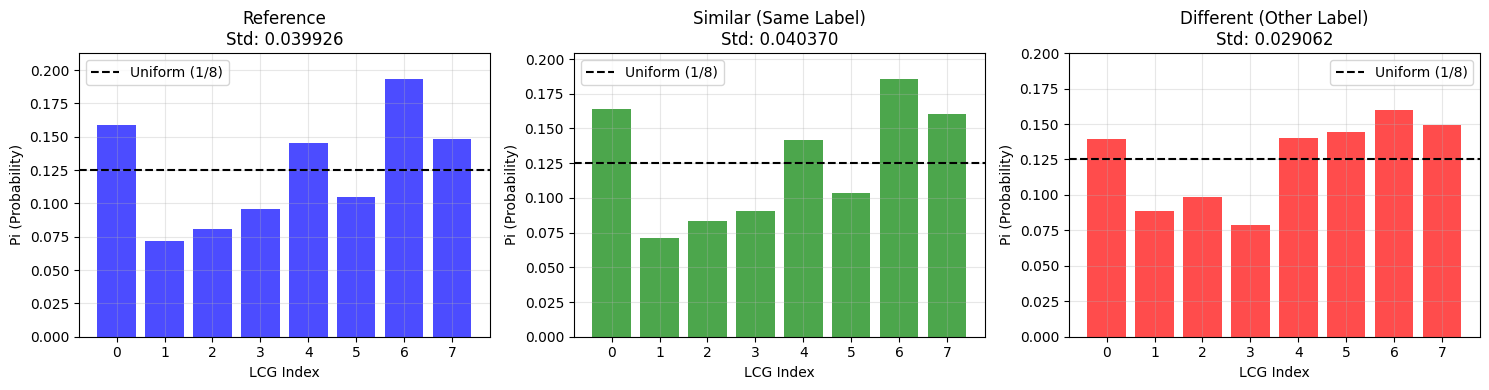

In [55]:
# 시각화: Pi 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
colors = ['blue', 'green', 'red']

for i, (coord, name, color) in enumerate(zip(coordinates, sample_names, colors)):
    ax = axes[i]
    ax.bar(range(8), coord, color=color, alpha=0.7)
    ax.set_xlabel('LCG Index')
    ax.set_ylabel('Pi (Probability)')
    ax.set_title(f'{name}\nStd: {coord.std():.6f}')
    ax.set_ylim([0, max(0.2, coord.max() * 1.1)])
    ax.axhline(y=1/8, color='black', linestyle='--', label='Uniform (1/8)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [61]:
# 더 자세한 분석: Distance의 variation
print("\n=== Distance Statistics Across Samples ===")
all_dists = np.array([distances[0], distances[1], distances[2]])

print("\nPer-LCG distance variance (across 3 samples):")
for lcg_idx in range(8):
    lcg_dists = all_dists[:, lcg_idx]
    print(f"LCG {lcg_idx}: mean={lcg_dists.mean():.6f}, std={lcg_dists.std():.6f}, range=[{lcg_dists.min():.6f}, {lcg_dists.max():.6f}]")

print("\nPer-Sample distance variance (across 8 LCGs):")
for sample_idx, name in enumerate(sample_names):
    sample_dists = all_dists[sample_idx]
    print(f"{name}: mean={sample_dists.mean():.6f}, std={sample_dists.std():.6f}")


=== Distance Statistics Across Samples ===

Per-LCG distance variance (across 3 samples):
LCG 0: mean=0.309399, std=0.009182, range=[0.298793, 0.321189]
LCG 1: mean=0.343962, std=0.017074, range=[0.321464, 0.362804]
LCG 2: mean=0.337719, std=0.016265, range=[0.316018, 0.355175]
LCG 3: mean=0.337157, std=0.010087, range=[0.327227, 0.350991]
LCG 4: mean=0.313148, std=0.012168, range=[0.298568, 0.328352]
LCG 5: mean=0.323370, std=0.019637, range=[0.297047, 0.344197]
LCG 6: mean=0.301737, std=0.009697, range=[0.291942, 0.314946]
LCG 7: mean=0.309786, std=0.011075, range=[0.295392, 0.322329]

Per-Sample distance variance (across 8 LCGs):
Reference: mean=0.322800, std=0.016475
Similar (Same Label): mean=0.337498, std=0.016838
Different (Other Label): mean=0.305806, std=0.012685


In [57]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

@torch.no_grad()
def collect_all_source_assignments(model, loaders, sources, device):
    """
    모든 source의 모든 샘플에 대해 LCG assignment 수집
    
    Returns:
        assignments: [N_total] - 각 샘플이 어느 LCG node에 할당되었는지
        source_labels: [N_total] - 각 샘플이 어느 source에서 왔는지
    """
    lcg_feat, lcg_struct = model.latent_graph()  # [M, K, D], [M, K, K]
    M, K, D = lcg_feat.shape
    
    all_assignments = []
    all_source_labels = []
    
    for src_idx, src in enumerate(sources):
        loader = loaders[src]
        
        for batch in loader:
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) 
                    for k, v in batch.items()}
            
            # desc/name/value gather
            desc_embeddings, name_embeddings, value_embeddings = [], [], []
            if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
                desc_embeddings.append(batch['cat_desc_embeddings'])
                name_embeddings.append(batch['cat_name_embeddings'])
                value_embeddings.append(batch['cat_value_embeddings'])
            if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
                desc_embeddings.append(batch['num_desc_embeddings'])
                name_embeddings.append(batch['num_name_embeddings'])
                value_embeddings.append(batch['num_prompt_embeddings'])

            name = torch.cat(name_embeddings, dim=1)
            value = torch.cat(value_embeddings, dim=1)
            
            B = value.size(0)
            N = value.size(1)

            # CLS + value
            x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

            # GAT forward
            last_att = None
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x_basis)
                basis_outputs, att = model.basis_layers[l](name, norm_x)
                last_att = att
                x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

            # Source features (CLS 제외)
            src_feat = x_basis[:, 1:, :]  # [B, N, D]
            
            # Affinity (Var-Var, CLS 제외)
            src_str = 1.0 - last_att[:, 0, 1:, 1:]  # [B, N, N]
            
            # Expand for M LCGs
            src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
            src_str_exp = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
            
            lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
            lcg_str_exp = lcg_struct.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)
            
            # FGW 계산
            dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
            tau = model.graph_quantizer.tau
            M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))
            
            a = torch.ones(B*M, N, device=device) / N
            b = torch.ones(B*M, K, device=device) / K
            
            alpha = model.graph_quantizer.alpha
            reg = model.graph_quantizer.reg
            
            result = solve_gromov_batch(
                src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
                a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
            )
            
            # Transport Plan: [B*M, N, K] → [B, M, N, K]
            plan = result.plan.reshape(B, M, N, K)
            
            # 각 샘플의 각 node가 어느 LCG node에 가장 많이 할당되었는지
            # Plan shape: [B, M, N, K]
            # Max over (M, K) → 어느 (LCG, Node)에 가장 많이?
            plan_flat = plan.reshape(B, M*K, N)  # [B, M*K, N]
            
            for b in range(B):
                for n in range(N):
                    # 이 node의 transport plan: [M*K]
                    transport = plan_flat[b, :, n].detach().cpu().numpy()
                    
                    # 가장 높은 할당을 받은 (LCG, Node)
                    best_idx = np.argmax(transport)
                    
                    all_assignments.append(best_idx)
                    all_source_labels.append(src_idx)
    
    return np.array(all_assignments), np.array(all_source_labels)

In [58]:
def plot_codebook_usage_argmax(assignments, source_labels, sources, M=8, K=8):
    """
    Argmax 기반 codebook usage 시각화
    
    Args:
        assignments: [N_total] - LCG*K index (0~63)
        source_labels: [N_total] - source index (0~3)
        sources: list of source names
        M: number of LCGs
        K: number of nodes per LCG
    """
    # 무지개 색상 (8개 LCG)
    colors = plt.cm.rainbow(np.linspace(0, 1, M))
    
    # LCG별, Node별 카운트
    counts = np.zeros((M, K))
    
    for assignment in assignments:
        lcg_idx = assignment // K
        node_idx = assignment % K
        if lcg_idx < M and node_idx < K:
            counts[lcg_idx, node_idx] += 1
    
    # Plot
    fig, ax = plt.subplots(figsize=(18, 6))
    
    x_positions = []
    bar_colors = []
    bar_heights = []
    
    current_x = 0
    for m in range(M):
        for k in range(K):
            x_positions.append(current_x)
            bar_colors.append(colors[m])
            bar_heights.append(counts[m, k])
            current_x += 1
    
    bars = ax.bar(x_positions, bar_heights, color=bar_colors, edgecolor='black', linewidth=0.5)
    
    # X-axis labels
    ax.set_xlabel('LCG Node Index (Color=Graph ID)', fontsize=14)
    ax.set_ylabel('Selection Count', fontsize=14)
    ax.set_title('Best Init: Codebook Usage (Count of Argmax)', fontsize=16)
    
    # X-ticks
    ax.set_xticks(range(0, M*K, 5))
    ax.set_xticklabels(range(0, M*K, 5))
    
    # Grid
    ax.grid(axis='y', alpha=0.3)
    
    # LCG 경계선
    for m in range(1, M):
        ax.axvline(x=m*K - 0.5, color='black', linewidth=2, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print("\n=== Codebook Usage Statistics (Argmax) ===")
    total_assignments = len(assignments)
    print(f"Total assignments: {total_assignments}")
    
    for m in range(M):
        lcg_count = counts[m].sum()
        print(f"LCG {m}: {int(lcg_count):5d} ({lcg_count/total_assignments*100:.1f}%)")
        
        # 가장 많이 사용된 node
        max_node = np.argmax(counts[m])
        max_count = counts[m, max_node]
        print(f"  → Most used node: {max_node} ({int(max_count)} times)")

Total samples collected: 41010
Assignment range: [0, 63]


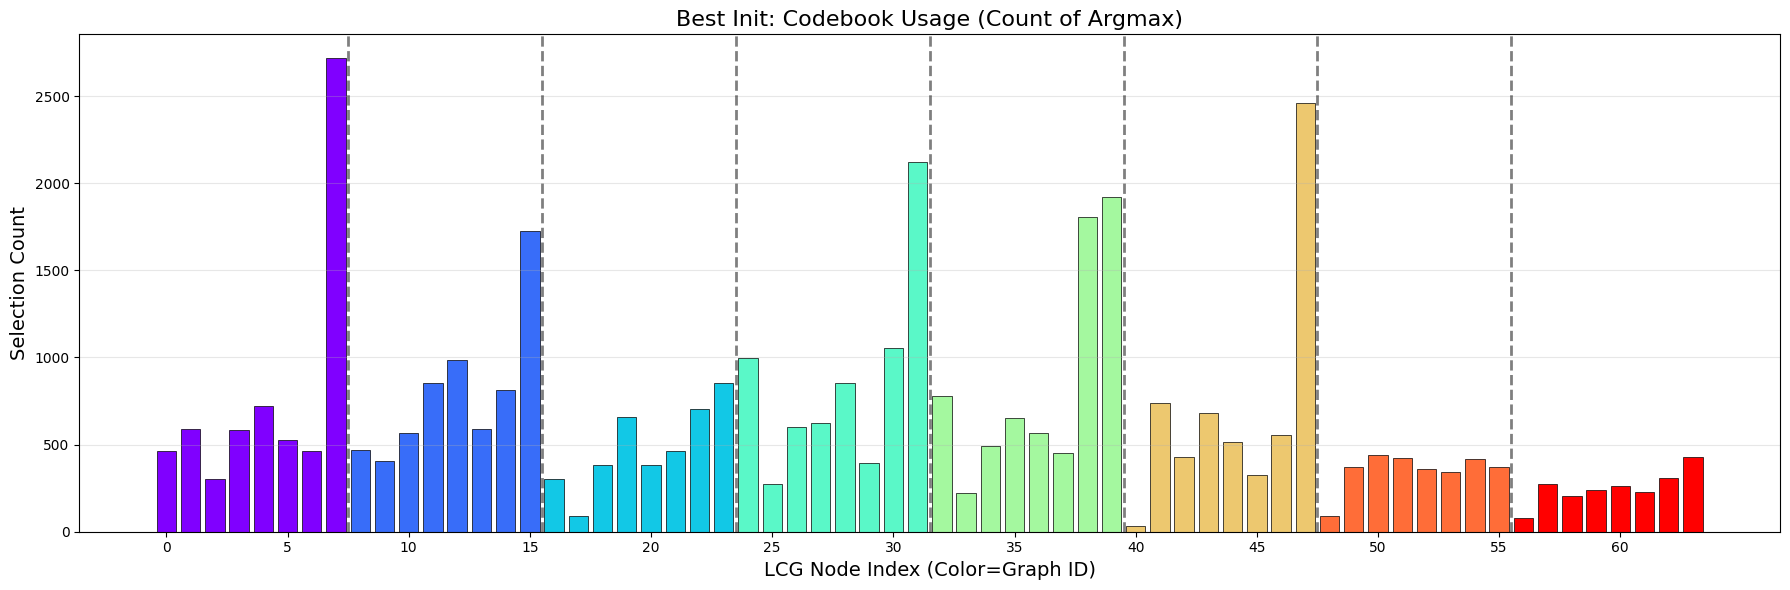


=== Codebook Usage Statistics (Argmax) ===
Total assignments: 41010
LCG 0:  6380 (15.6%)
  → Most used node: 7 (2718 times)
LCG 1:  6401 (15.6%)
  → Most used node: 7 (1723 times)
LCG 2:  3839 (9.4%)
  → Most used node: 7 (853 times)
LCG 3:  6907 (16.8%)
  → Most used node: 7 (2119 times)
LCG 4:  6896 (16.8%)
  → Most used node: 7 (1923 times)
LCG 5:  5738 (14.0%)
  → Most used node: 7 (2461 times)
LCG 6:  2822 (6.9%)
  → Most used node: 2 (439 times)
LCG 7:  2027 (4.9%)
  → Most used node: 7 (428 times)


In [59]:
# 실행
print("Collecting assignments from all sources...")
assignments, source_labels = collect_all_source_assignments(
    joint_model_pretrain, loaders, sources, device
)

print(f"Total samples collected: {len(assignments)}")
print(f"Assignment range: [{assignments.min()}, {assignments.max()}]")

# 시각화
plot_codebook_usage_argmax(assignments, source_labels, sources, M=8, K=8)

## coordinates

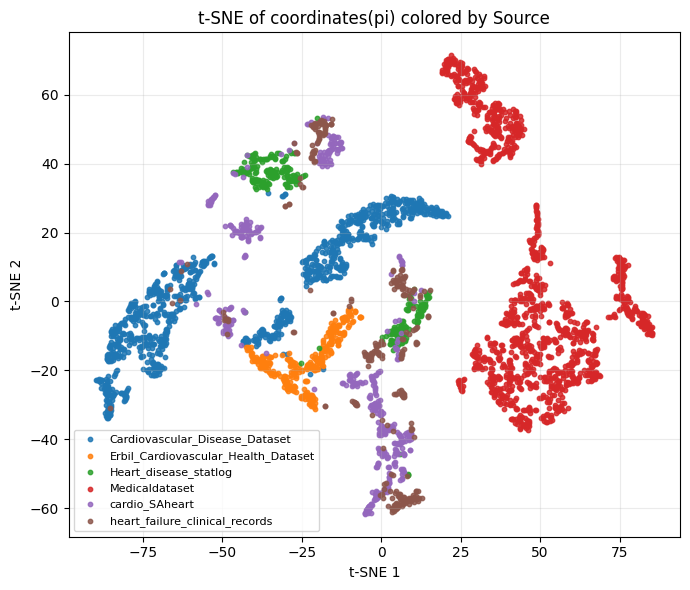

In [64]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

@torch.no_grad()
def collect_all_coordinates(model, loaders, device):
    model.eval()
    coords, labels, sources = [], [], []

    for src_name, loader in loaders.items():
        for batch in loader:
            batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

            # LCG 경로를 타면서 pi 계산되게
            _ = model.predict(batch, return_all=True)

            pi = model.graph_quantizer.last_pi  # [B, M]
            if pi is None:
                raise RuntimeError("last_pi가 None임. use_lcg=True인지 확인해.")

            coords.append(pi.detach().cpu().numpy())
            sources.extend([src_name] * pi.shape[0])

            if "y" in batch:
                labels.extend(batch["y"].detach().cpu().numpy().reshape(-1).tolist())
            else:
                labels.extend([-1] * pi.shape[0])

    coords = np.concatenate(coords, axis=0)  # [N_total, M]
    labels = np.array(labels)
    sources = np.array(sources, dtype=object)
    return coords, labels, sources


# 1) collect
coords, labels, sources = collect_all_coordinates(model, loaders, device)
N = coords.shape[0]

# 2) t-SNE
perp = max(5, min(30, (N - 1) // 3))
tsne = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=42)
xy = tsne.fit_transform(coords)  # [N,2]

# 3) plot: color by SOURCE (no KMeans)
uniq_sources = sorted(list(set(sources.tolist())))

plt.figure(figsize=(7, 6))
for s in uniq_sources:
    mask = (sources == s)
    plt.scatter(
        xy[mask, 0], xy[mask, 1],
        s=10, alpha=0.85, label=str(s)
    )

plt.title("t-SNE of coordinates(pi) colored by Source")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8, frameon=True, loc="best")
plt.tight_layout()
plt.show()


[Medicaldataset] collected: N=1319, M=8, labels=Counter({1: 810, 0: 509})


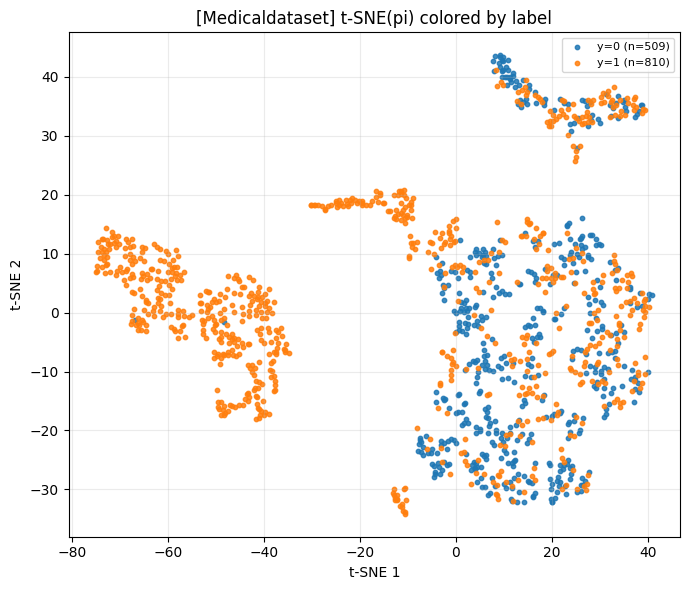

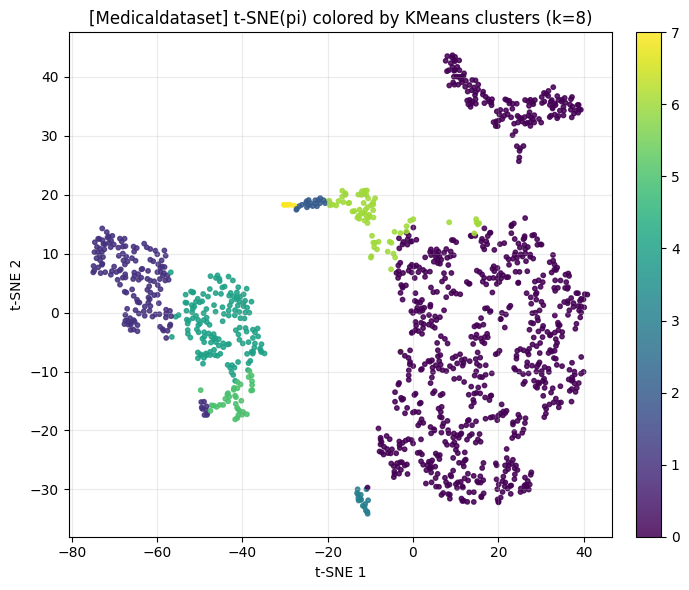


[Cluster x Label counts]
cluster | y=0 | y=1 | total
---------------------------
      0 |   505 |   354 |   859
      1 |     1 |   158 |   159
      2 |     0 |    19 |    19
      3 |     0 |    16 |    16
      4 |     1 |   150 |   151
      5 |     0 |    37 |    37
      6 |     2 |    70 |    72
      7 |     0 |     6 |     6


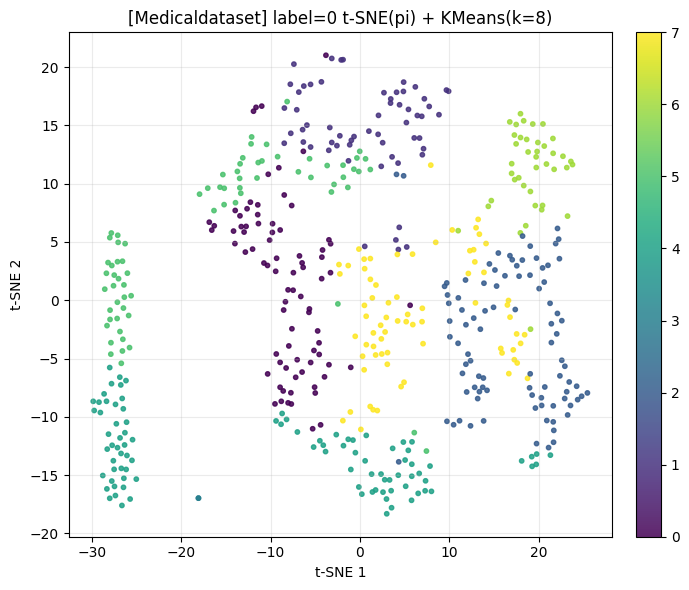


[label=0] farthest centroids: (1, 3), L2=0.019542


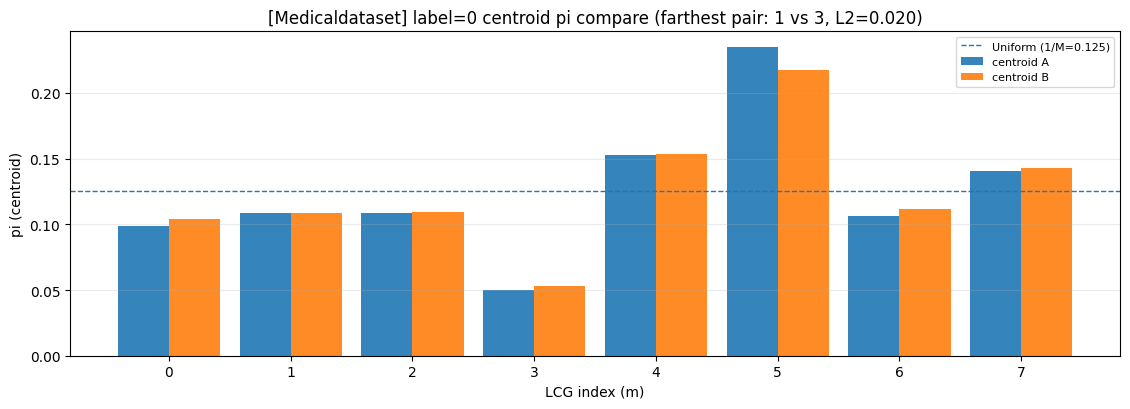

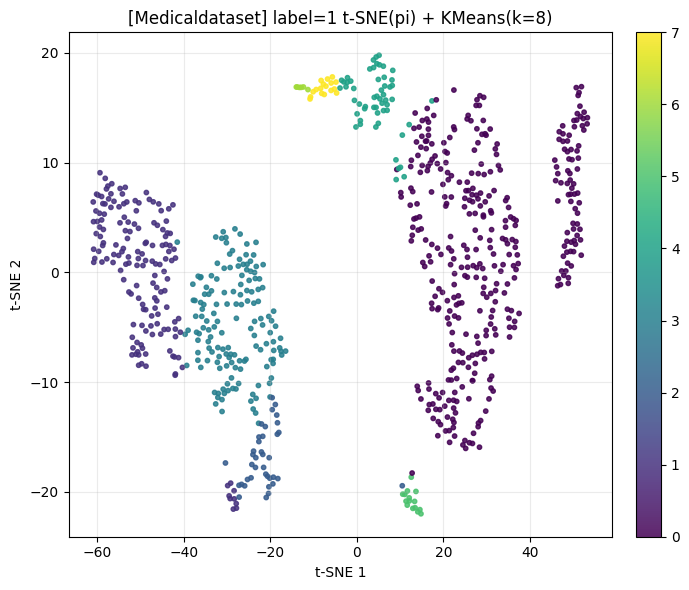


[label=1] farthest centroids: (5, 6), L2=0.039721


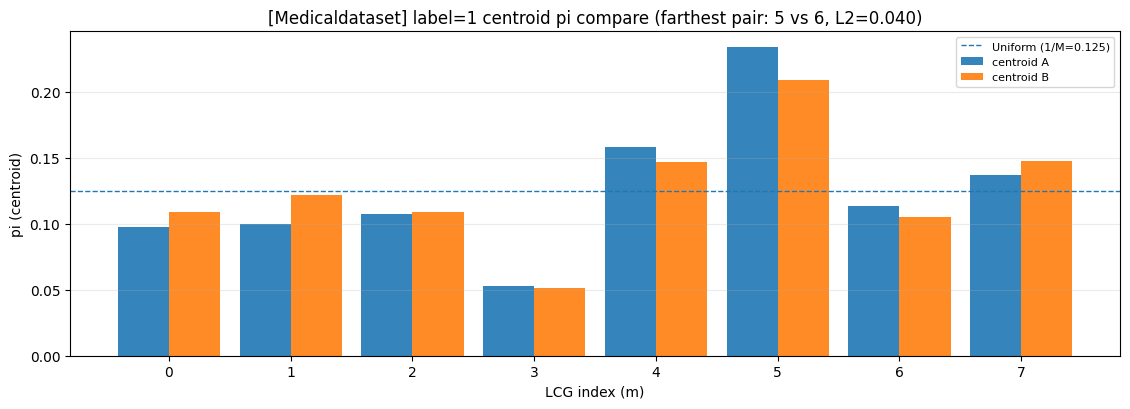

In [70]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from collections import Counter

# -----------------------------
# 0) Collect pi for ONE source
# -----------------------------
@torch.no_grad()
def collect_pi_for_one_source(model, loader, device):
    model.eval()
    pis, ys = [], []
    for batch in loader:
        batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
        _ = model.predict(batch, return_all=True)  # last_pi 계산
        pi = model.graph_quantizer.last_pi
        if pi is None:
            raise RuntimeError("last_pi is None. use_lcg=True / predict 경로 확인.")
        pis.append(pi.detach().cpu().numpy())
        ys.append(batch["y"].detach().cpu().numpy().reshape(-1).astype(int))
    pi_all = np.concatenate(pis, axis=0)  # [N, M]
    y_all  = np.concatenate(ys, axis=0)   # [N]
    return pi_all, y_all


# -----------------------------
# 1) t-SNE helper
# -----------------------------
def tsne_2d(X, seed=42):
    N = X.shape[0]
    perp = max(5, min(30, (N - 1) // 3))  # 안전
    tsne = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=seed)
    return tsne.fit_transform(X)


# -----------------------------
# 2) Plot helpers
# -----------------------------
def plot_tsne_by_label(xy, y, title):
    plt.figure(figsize=(7, 6))
    for lab in sorted(set(y.tolist())):
        idx = np.where(y == lab)[0]
        plt.scatter(xy[idx, 0], xy[idx, 1], s=10, alpha=0.85, label=f"y={lab} (n={len(idx)})")
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=8, frameon=True, loc="best")
    plt.tight_layout()
    plt.show()

def plot_tsne_by_cluster(xy, cid, title):
    plt.figure(figsize=(7, 6))
    sc = plt.scatter(xy[:, 0], xy[:, 1], c=cid, s=10, alpha=0.85)
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.25)
    plt.colorbar(sc, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def print_cluster_label_table(cid, y):
    # cluster x label count 출력
    clusters = sorted(set(cid.tolist()))
    labels   = sorted(set(y.tolist()))
    table = {c: {lab: 0 for lab in labels} for c in clusters}
    for c, lab in zip(cid, y):
        table[int(c)][int(lab)] += 1

    print("\n[Cluster x Label counts]")
    header = "cluster | " + " | ".join([f"y={lab}" for lab in labels]) + " | total"
    print(header)
    print("-" * len(header))
    for c in clusters:
        row = [table[c][lab] for lab in labels]
        print(f"{c:>7} | " + " | ".join([f"{v:>5}" for v in row]) + f" | {sum(row):>5}")

def farthest_centroid_pair(centroids):
    K = centroids.shape[0]
    dmat = np.linalg.norm(centroids[:, None, :] - centroids[None, :, :], axis=2)
    np.fill_diagonal(dmat, -np.inf)
    a, b = np.unravel_index(np.argmax(dmat), dmat.shape)
    return int(a), int(b), float(dmat[a, b])

def plot_centroid_pi_compare(cA, cB, title):
    cA = np.asarray(cA); cB = np.asarray(cB)
    M = cA.shape[0]
    x = np.arange(M)
    w = 0.42
    uniform = 1.0 / M

    plt.figure(figsize=(max(9, 0.8*M + 5), 4.2))
    plt.bar(x - w/2, cA, width=w, label="centroid A", alpha=0.9)
    plt.bar(x + w/2, cB, width=w, label="centroid B", alpha=0.9)
    plt.axhline(uniform, linestyle="--", linewidth=1, label=f"Uniform (1/M={uniform:.3f})")
    plt.xticks(x, [str(i) for i in x])
    plt.xlabel("LCG index (m)")
    plt.ylabel("pi (centroid)")
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend(fontsize=8, frameon=True, loc="best")
    plt.tight_layout()
    plt.show()


# -----------------------------
# 3) Main routine (Medicaldataset only)
# -----------------------------
source_name = "Medicaldataset"  # <- 너가 말한 걸로 고정
loader = loaders[source_name]

# (A) collect
pi_all, y_all = collect_pi_for_one_source(model, loader, device)
N, M = pi_all.shape
print(f"[{source_name}] collected: N={N}, M={M}, labels={Counter(y_all.tolist())}")

# (1) 전체 pi로 clustering + label로 어떻게 보이는지
k_all = min(8, N)  # 일단 8, 샘플 적으면 자동 축소
km_all = KMeans(n_clusters=k_all, random_state=42, n_init=20)
cid_all = km_all.fit_predict(pi_all)

xy_all = tsne_2d(pi_all, seed=42)
plot_tsne_by_label(xy_all, y_all, title=f"[{source_name}] t-SNE(pi) colored by label")
plot_tsne_by_cluster(xy_all, cid_all, title=f"[{source_name}] t-SNE(pi) colored by KMeans clusters (k={k_all})")
print_cluster_label_table(cid_all, y_all)

# (2) label 내부에서 clustering + centroid 비교
def within_label_clustering_and_compare(pi_all, y_all, lab, k=8):
    idx = np.where(y_all == lab)[0]
    X = pi_all[idx]
    n = X.shape[0]
    if n < 2:
        print(f"\n[label={lab}] samples too few: n={n}")
        return
    k_lab = min(k, n)  # 샘플 수보다 클러스터 많으면 안됨
    if k_lab < 2:
        print(f"\n[label={lab}] clusters too few: k={k_lab}")
        return

    km = KMeans(n_clusters=k_lab, random_state=42, n_init=20)
    cid = km.fit_predict(X)
    C = km.cluster_centers_  # [k_lab, M]

    # label 내부 t-SNE (cluster로 색)
    xy = tsne_2d(X, seed=42)
    plot_tsne_by_cluster(xy, cid, title=f"[{source_name}] label={lab} t-SNE(pi) + KMeans(k={k_lab})")

    # (2-1/2-2) farthest centroid pair 비교
    a, b, dist = farthest_centroid_pair(C)
    print(f"\n[label={lab}] farthest centroids: ({a}, {b}), L2={dist:.6f}")
    plot_centroid_pi_compare(
        C[a], C[b],
        title=f"[{source_name}] label={lab} centroid pi compare (farthest pair: {a} vs {b}, L2={dist:.3f})"
    )

# label 0
within_label_clustering_and_compare(pi_all, y_all, lab=0, k=8)
# label 1
within_label_clustering_and_compare(pi_all, y_all, lab=1, k=8)


In [71]:
import numpy as np
import torch
import pandas as pd
from sklearn.cluster import KMeans

@torch.no_grad()
def collect_coords_one_source(model, loader, device):
    model.eval()
    coords = []
    ys = []

    for batch in loader:
        batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        # pi 계산되게 (use_lcg=True여야 last_pi가 채워짐)
        _ = model.predict(batch, return_all=True)

        pi = model.graph_quantizer.last_pi  # [B, M]
        if pi is None:
            raise RuntimeError("last_pi가 None임. args.use_lcg=True인지, model.predict가 LCG 경로 타는지 확인.")

        coords.append(pi.detach().cpu().numpy())

        if "y" not in batch:
            raise RuntimeError("batch에 'y'가 없음.")
        ys.append(batch["y"].detach().cpu().numpy().reshape(-1))

    coords = np.concatenate(coords, axis=0)  # [N, M]
    ys = np.concatenate(ys, axis=0).astype(int)  # [N]
    return coords, ys


def kmeans_purity_table(coords, ys, k=8, seed=42):
    """
    coords: [N, M] (pi)
    ys: [N] (0/1)
    """
    km = KMeans(n_clusters=k, random_state=seed, n_init=20)
    cid = km.fit_predict(coords)

    # cluster x label count
    ct = pd.crosstab(cid, ys)  # rows=cluster, cols=label
    for col in [0, 1]:
        if col not in ct.columns:
            ct[col] = 0
    ct = ct[[0, 1]]

    n = ct.sum(axis=1)
    p1 = (ct[1] / n).fillna(0.0)
    p0 = (ct[0] / n).fillna(0.0)
    purity = np.maximum(p0, p1)
    majority = np.where(p1 >= 0.5, 1, 0)

    summary = pd.DataFrame({
        "cluster": ct.index.astype(int),
        "n": n.values.astype(int),
        "y=0": ct[0].values.astype(int),
        "y=1": ct[1].values.astype(int),
        "p(y=1)": p1.values,
        "purity": purity.values,
        "majority_label": majority,
    }).sort_values("cluster").reset_index(drop=True)

    # 비율표(클러스터 내부에서 label 비율)
    ratio = ct.div(ct.sum(axis=1), axis=0).fillna(0.0)
    ratio.columns = [f"p(y={c})" for c in ratio.columns]
    ratio = ratio.reset_index().rename(columns={"row_0": "cluster", "index": "cluster"})

    return summary, ratio, ct


@torch.no_grad()
def run_sourcewise_purity(model, loaders, device, k=8, seed=42):
    out = {}
    for src_name, loader in loaders.items():
        coords, ys = collect_coords_one_source(model, loader, device)

        summary, ratio, ct = kmeans_purity_table(coords, ys, k=k, seed=seed)

        base_p1 = ys.mean()
        print(f"\n=== [{src_name}] ===")
        print(f"N={len(ys)} | base p(y=1)={base_p1:.4f} | KMeans(k={k}) on pi")
        print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
        print("\n[cluster-wise label ratio]")
        print(ratio.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

        out[src_name] = {
            "coords": coords,
            "ys": ys,
            "summary": summary,
            "ratio": ratio,
            "count_table": ct
        }
    return out


# ---- 실행 예시 ----
# k=8은 너 LCG 개수(M)랑 맞추는 게 보통 자연스러움
results = run_sourcewise_purity(model, loaders, device, k=8, seed=42)



=== [Medicaldataset] ===
N=1319 | base p(y=1)=0.6141 | KMeans(k=8) on pi
 cluster   n  y=0  y=1  p(y=1)  purity  majority_label
       0 859  505  354  0.4121  0.5879               0
       1 159    1  158  0.9937  0.9937               1
       2  19    0   19  1.0000  1.0000               1
       3  16    0   16  1.0000  1.0000               1
       4 151    1  150  0.9934  0.9934               1
       5  37    0   37  1.0000  1.0000               1
       6  72    2   70  0.9722  0.9722               1
       7   6    0    6  1.0000  1.0000               1

[cluster-wise label ratio]
 cluster  p(y=0)  p(y=1)
       0  0.5879  0.4121
       1  0.0063  0.9937
       2  0.0000  1.0000
       3  0.0000  1.0000
       4  0.0066  0.9934
       5  0.0000  1.0000
       6  0.0278  0.9722
       7  0.0000  1.0000

=== [Cardiovascular_Disease_Dataset] ===
N=1000 | base p(y=1)=0.5800 | KMeans(k=8) on pi
 cluster   n  y=0  y=1  p(y=1)  purity  majority_label
       0 133   18  115  0.8647  0

Using source: Medicaldataset


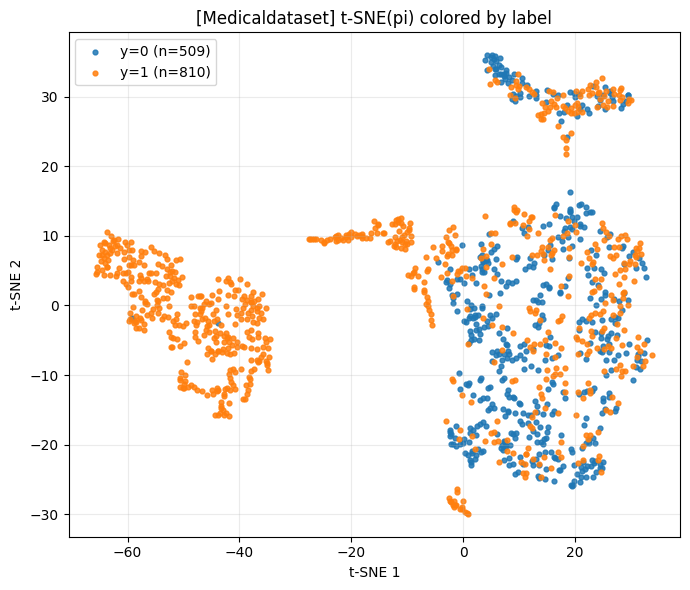

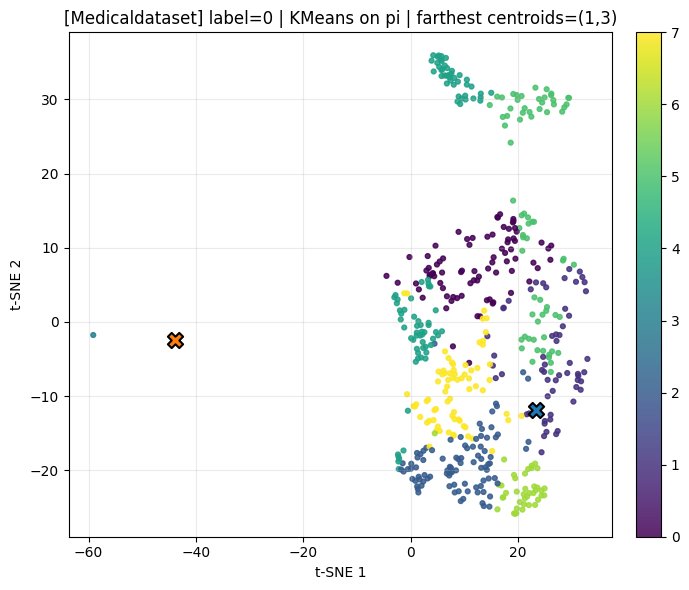

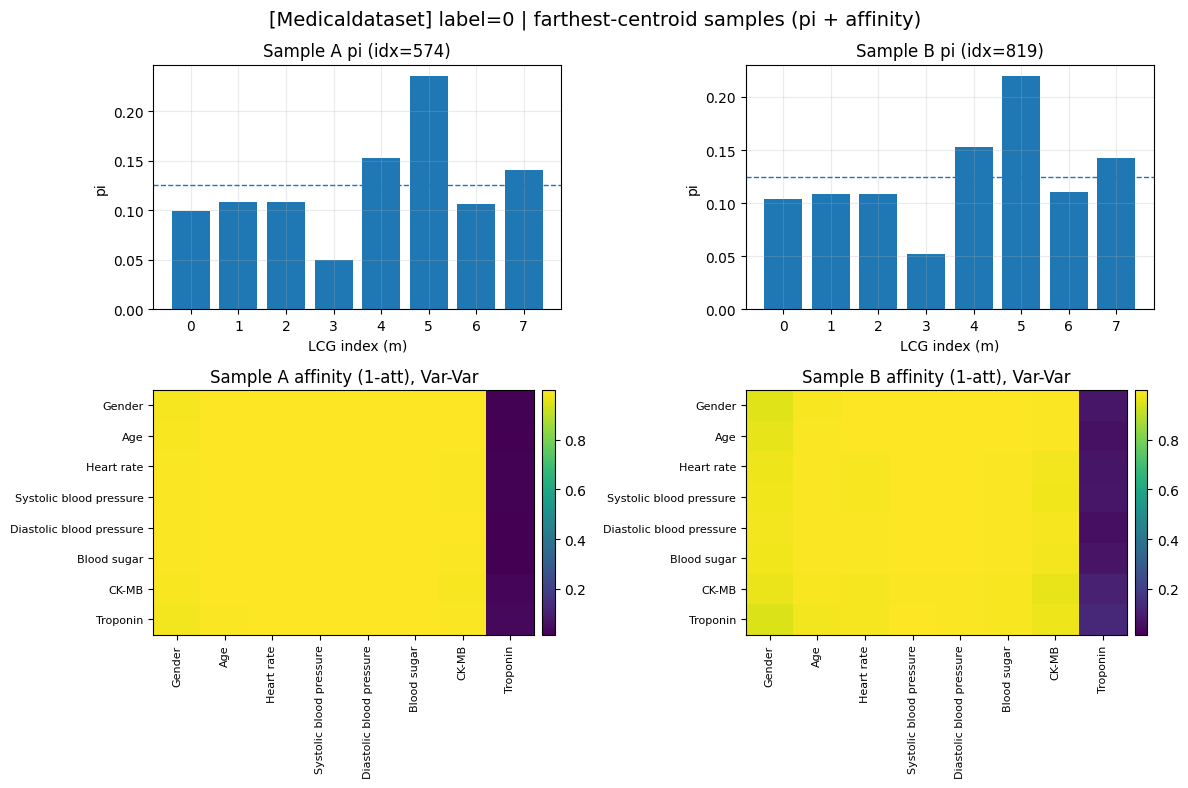

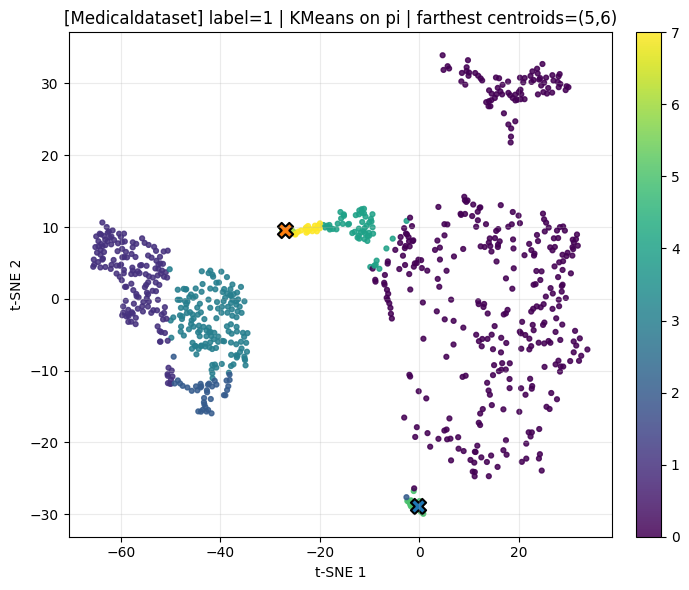

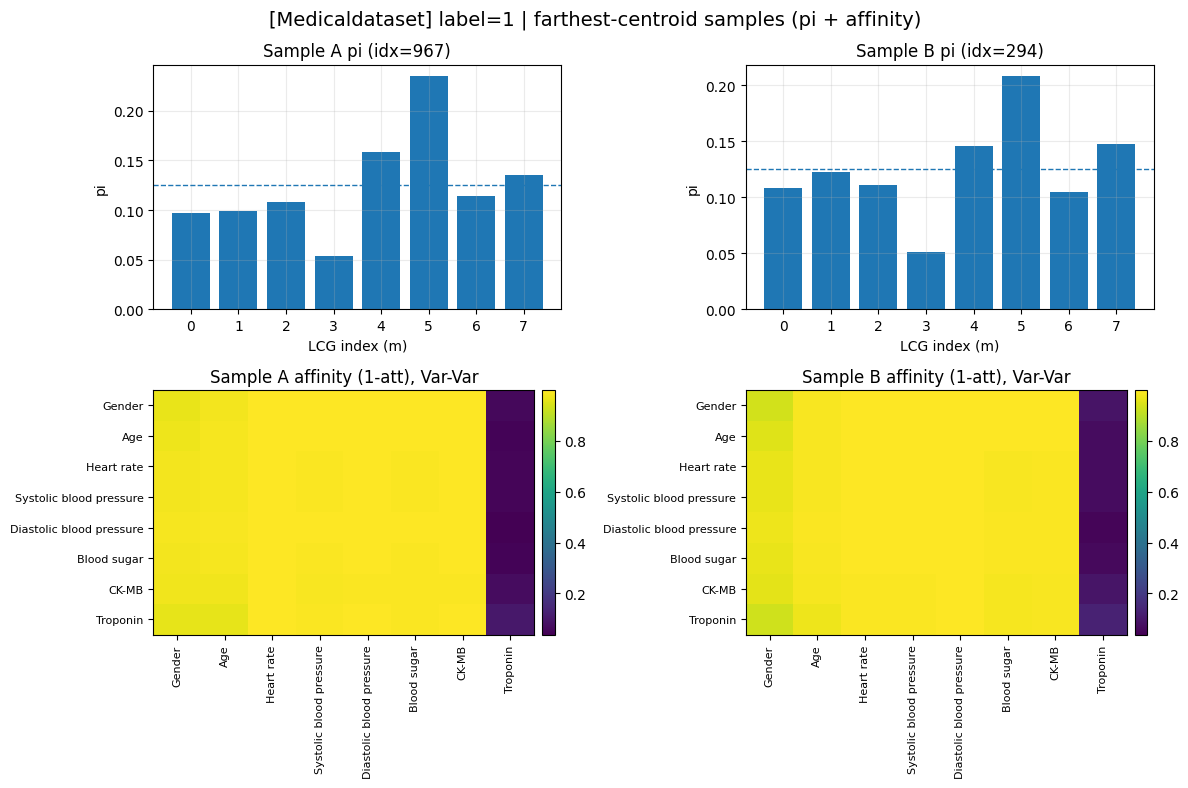

In [72]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# ----------------------------
# 0) Medicaldataset loader 찾기
# ----------------------------
def get_loader_by_key(loaders, key="Medicaldataset"):
    for k in loaders.keys():
        if str(k).lower() == str(key).lower():
            return k, loaders[k]
    # fallback: 부분매칭
    for k in loaders.keys():
        if str(key).lower() in str(k).lower():
            return k, loaders[k]
    raise KeyError(f"'{key}' loader not found. available={list(loaders.keys())}")

# ------------------------------------------------------
# 1) Medicaldataset 전체에서 pi + affinity(= _last_P_basis) 수집
# ------------------------------------------------------
@torch.no_grad()
def collect_pi_and_affinity_for_one_source(model, loader, device):
    model.eval()
    pis = []
    ys = []
    affs = []
    names = []  # var names per sample (list)

    for batch in loader:
        batch_t = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        # pi / plan / _last_P_basis 갱신되게
        _ = model.predict(batch_t, return_all=True)

        pi = model.graph_quantizer.last_pi          # [B, M] (detached)
        P  = model._last_P_basis                    # [B, N, N] (1 - attention, Var-Var)

        if pi is None or P is None:
            raise RuntimeError("pi 또는 _last_P_basis가 None. args.use_lcg=True인지 확인.")

        # feature names (배치 단위로 얻고, 샘플별로 복사 저장)
        var_names = extract_feature_names(batch)    # 네가 이미 만들어둔 함수

        B = pi.shape[0]
        for b in range(B):
            pis.append(pi[b].detach().cpu().numpy())          # [M]
            ys.append(int(batch_t["y"][b].item()))            # scalar
            affs.append(P[b].detach().cpu().numpy())          # [N,N]
            names.append(var_names)

    pis = np.stack(pis, axis=0)     # [N_total, M]
    ys  = np.array(ys, dtype=int)   # [N_total]
    return pis, ys, affs, names

# ------------------------------------------------------
# 2) label 내부 KMeans + "가장 먼 centroid 2개" + 대표 샘플 선택
# ------------------------------------------------------
def kmeans_farthest_centroids_pick_samples(pis, ys, label, k=8, seed=42):
    idx = np.where(ys == label)[0]
    if len(idx) < 2:
        raise ValueError(f"label={label} samples too few: {len(idx)}")

    X = pis[idx]  # [n_lab, M]
    k_eff = min(k, len(idx))
    km = KMeans(n_clusters=k_eff, random_state=seed, n_init=20)
    cid = km.fit_predict(X)
    C = km.cluster_centers_  # [k_eff, M]

    # centroid pairwise distance -> farthest pair
    dist = np.linalg.norm(C[:, None, :] - C[None, :, :], axis=-1)  # [k,k]
    np.fill_diagonal(dist, -np.inf)
    a, b = np.unravel_index(np.argmax(dist), dist.shape)

    # 각 centroid에 가장 가까운 "원 샘플" 1개씩
    def pick_nearest(centroid):
        d = np.linalg.norm(X - centroid[None, :], axis=1)
        return idx[int(np.argmin(d))]

    samp_a = pick_nearest(C[a])
    samp_b = pick_nearest(C[b])

    return {
        "idx_lab": idx,          # label subset indices (global)
        "X_lab": X,              # pi subset
        "cid": cid,              # cluster id per subset sample
        "km": km,
        "centroid_pair": (a, b),
        "sample_pair": (samp_a, samp_b),  # global sample indices
    }

# ------------------------------------------------------
# 3) Plot: (i) label별 전체 tSNE, (ii) label 내부 cluster tSNE, (iii) 대표 2샘플 비교(pi+aff)
# ------------------------------------------------------
def plot_tsne_by_label(pis, ys, title_prefix="[Medicaldataset]", seed=42):
    N = pis.shape[0]
    perp = max(5, min(40, (N - 1) // 3))
    xy = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=seed).fit_transform(pis)

    plt.figure(figsize=(7, 6))
    for lab in [0, 1]:
        m = (ys == lab)
        plt.scatter(xy[m, 0], xy[m, 1], s=12, alpha=0.85, label=f"y={lab} (n={m.sum()})")
    plt.title(f"{title_prefix} t-SNE(pi) colored by label")
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.25)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()
    return xy

def plot_label_clusters_and_pick(xy_all, result, ys, label, title_prefix="[Medicaldataset]"):
    idx = result["idx_lab"]
    cid = result["cid"]
    samp_a, samp_b = result["sample_pair"]

    xy = xy_all[idx]  # subset coords in tSNE space

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(xy[:, 0], xy[:, 1], c=cid, s=12, alpha=0.85)
    # highlight picked samples
    ia = np.where(idx == samp_a)[0][0]
    ib = np.where(idx == samp_b)[0][0]
    plt.scatter(xy[ia, 0], xy[ia, 1], s=120, marker="X", edgecolors="black", linewidths=1.5)
    plt.scatter(xy[ib, 0], xy[ib, 1], s=120, marker="X", edgecolors="black", linewidths=1.5)

    a, b = result["centroid_pair"]
    plt.title(f"{title_prefix} label={label} | KMeans on pi | farthest centroids=({a},{b})")
    plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
    plt.grid(True, alpha=0.25)
    plt.colorbar(sc, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def plot_two_samples_pi_and_affinity(pis, affs, names, samp_a, samp_b, title):
    pi_a = pis[samp_a]
    pi_b = pis[samp_b]
    A_a  = affs[samp_a]
    A_b  = affs[samp_b]

    M = pi_a.shape[0]
    uniform = 1.0 / M

    # affinity color scale 통일
    vmin = min(A_a.min(), A_b.min())
    vmax = max(A_a.max(), A_b.max())

    # var names (y축 라벨용)
    var_names_a = names[samp_a]
    var_names_b = names[samp_b]
    # 보통 동일하겠지만, 혹시 달라도 각자 사용
    N_a = A_a.shape[0]
    N_b = A_b.shape[0]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # (1) pi bars
    ax = axes[0, 0]
    ax.bar(np.arange(M), pi_a)
    ax.axhline(uniform, linestyle="--", linewidth=1)
    ax.set_title(f"Sample A pi (idx={samp_a})")
    ax.set_xlabel("LCG index (m)"); ax.set_ylabel("pi")
    ax.grid(True, alpha=0.25)

    ax = axes[0, 1]
    ax.bar(np.arange(M), pi_b)
    ax.axhline(uniform, linestyle="--", linewidth=1)
    ax.set_title(f"Sample B pi (idx={samp_b})")
    ax.set_xlabel("LCG index (m)"); ax.set_ylabel("pi")
    ax.grid(True, alpha=0.25)

    # (2) affinity heatmaps (Var-Var)
    ax = axes[1, 0]
    im1 = ax.imshow(A_a, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title("Sample A affinity (1-att), Var-Var")
    ax.set_xticks(range(N_a)); ax.set_yticks(range(N_a))
    ax.set_xticklabels(var_names_a, rotation=90, fontsize=8)
    ax.set_yticklabels(var_names_a, fontsize=8)
    fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.02)

    ax = axes[1, 1]
    im2 = ax.imshow(A_b, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title("Sample B affinity (1-att), Var-Var")
    ax.set_xticks(range(N_b)); ax.set_yticks(range(N_b))
    ax.set_xticklabels(var_names_b, rotation=90, fontsize=8)
    ax.set_yticklabels(var_names_b, fontsize=8)
    fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.02)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# ============================
# RUN (Medicaldataset only)
# ============================
src_key, medical_loader = get_loader_by_key(loaders, "Medicaldataset")
print("Using source:", src_key)

pis, ys, affs, names = collect_pi_and_affinity_for_one_source(model, medical_loader, device)

# (A) 전체: tSNE(pi) colored by label
xy_all = plot_tsne_by_label(pis, ys, title_prefix=f"[{src_key}]")

# (B)(C) label 내부: KMeans(pi) + farthest centroid pair 비교
for lab in [0, 1]:
    res = kmeans_farthest_centroids_pick_samples(pis, ys, label=lab, k=8, seed=42)
    plot_label_clusters_and_pick(xy_all, res, ys, label=lab, title_prefix=f"[{src_key}]")

    samp_a, samp_b = res["sample_pair"]
    plot_two_samples_pi_and_affinity(
        pis, affs, names,
        samp_a, samp_b,
        title=f"[{src_key}] label={lab} | farthest-centroid samples (pi + affinity)"
    )


### Target

In [73]:
# Target 모델 로드



target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.1_kl_gamma-2.0_tau-0.2_target_data-heart_entropic_reg-0.01_description-None/50/20251225_051316/Embed:carte_Edge:mlp_A:gat_v1_S:50_20260102_235227.pt"
#target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Medicaldataset+Cardiovascular_Disease_Dataset+Heart_disease_statlog+Erbil_Cardiovascular_Health_Dataset+cardio_SAheart+heart_failure_clinical_records/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_struct_hidden_dim-192_fgw_alpha-1_alpha-0.7_vq_beta-0.1_kl_gamma-2.0_tau-0.2_target_data-heart_entropic_reg-0.01_description-None/50/20251224_141356/Embed:carte_Edge:mlp_A:gat_v1_S:50_20260102_225818.pt"
#target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4_entropictest3있음중요함!!/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-entropictest3/42/Embed:carte_Edge:mlp_A:gat_v1_S:42_20251202_182719.pt"
#target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-BASELINE3/42/Embed:carte_Edge:mlp_A:gat_v1_S:42_20251204_184247.pt"
target_ckpt = torch.load(target_rr_ckpt_path, map_location=device)
target_args = target_ckpt['args']

print("=== Target Checkpoint Info ===")
print(f"Epoch: {target_ckpt.get('epoch', 'unknown')}")
print(f"Val AUC: {target_ckpt.get('val_auc', 'unknown')}")
print(f"Threshold: {target_ckpt.get('threshold', 'unknown')}")
print(f"Keys: {list(target_ckpt.keys())}")

# Target 모델 초기화
target_rr_model = Model(
    target_args,
    target_args.input_dim,
    target_args.hidden_dim,
    target_args.output_dim,
    target_args.dropout_rate,
    target_args.llm_model,
    experiment_id="target_viz",
    mode="Few"
).to(device)

target_sd = target_ckpt['model_state_dict']
missing, unexpected = target_rr_model.load_state_dict(target_sd, strict=False)
print("\nTarget Model Loaded")
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

target_rr_model.eval()

=== Target Checkpoint Info ===
Epoch: 29
Val AUC: 0.8860593017694883
Threshold: 0.4261823296546936
Keys: ['model_state_dict', 'epoch', 'val_auc', 'val_auprc', 'threshold', 'args']

Target Model Loaded
Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph(
    (q_proj): Linear(in_features=768, out_features=192, bias=True)
    (k_proj): Linear(in_features=768, out_features=192, bias=True)
  )
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_laye

In [74]:
# Target 데이터 준비 - 간단하게
target_name = target_args.target_data
print(f"\nTarget dataset: {target_name}")

# loaders dict 확인
print(f"Available loaders: {list(loaders.keys())}")

# Target loader 찾기
if target_name in loaders:
    target_loader = loaders[target_name]
    print(f"✓ Found target loader: {target_name}")
else:
    print(f"✗ Target '{target_name}' not in loaders")
    print("Available sources:", list(loaders.keys()))
    # 아무거나 하나 쓰거나 물어보자
    target_loader = list(loaders.values())[0]
    print(f"Using first available loader instead")


Target dataset: heart
Available loaders: ['Medicaldataset', 'Cardiovascular_Disease_Dataset', 'Heart_disease_statlog', 'Erbil_Cardiovascular_Health_Dataset', 'cardio_SAheart', 'heart_failure_clinical_records']
✗ Target 'heart' not in loaders
Available sources: ['Medicaldataset', 'Cardiovascular_Disease_Dataset', 'Heart_disease_statlog', 'Erbil_Cardiovascular_Health_Dataset', 'cardio_SAheart', 'heart_failure_clinical_records']
Using first available loader instead


In [75]:
# Target 데이터 로드
from dataset.data_dataloaders import prepare_embedding_dataloaders

print(f"\nLoading target dataset: {target_args.target_data}")

r_t = prepare_embedding_dataloaders(target_args, target_args.target_data)
train_loader_t, val_loader_t, test_loader_t = r_t['loaders']
num_classes_t = r_t['num_classes']

print(f"✓ Target loaded")
print(f"  Num classes: {num_classes_t}")

# Test loader 사용
target_loader = test_loader_t
print(f"  Test samples: {len(test_loader_t.dataset)}")
# Target 샘플 수집
print("\nCollecting target samples...")
target_embeddings, target_affinities, target_labels, target_feature_names = collect_all_samples_from_source(
    target_rr_model, target_loader, target_args.target_data
)

print(f"Total collected: {len(target_embeddings)}")
print(f"Label 0: {(np.array(target_labels) == 0).sum()}")
print(f"Label 1: {(np.array(target_labels) == 1).sum()}")


Loading target dataset: heart
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart.pkl
>>> [DataLoader] Created isolated generator with seed 50
Training data size: 550
Validation data size: 184
Test data size: 184
✓ Target loaded
  Num classes: 2
  Test samples: 184

Total collected: 184
Label 0: 82
Label 1: 102


In [76]:
# Frobenius distance 계산
print("\nComputing Frobenius distances...")
target_emb_distances, target_aff_distances = compute_frobenius_distances(
    target_embeddings, target_affinities
)


Computing Frobenius distances...


In [77]:
# Reference, Similar, Different 선택
target_ref_idx = 0

target_sim_idx, target_diff_idx = find_most_similar_and_different_by_label(
    target_ref_idx, target_aff_distances, target_labels
)

print(f"\n=== Target Sample Selection ===")
print(f"Reference: idx={target_ref_idx}, label={target_labels[target_ref_idx]}")
print(f"Similar (same label): idx={target_sim_idx}, label={target_labels[target_sim_idx]}")
print(f"  → Affinity Frob: {target_aff_distances[target_ref_idx, target_sim_idx]:.4f}")
print(f"Different (other label): idx={target_diff_idx}, label={target_labels[target_diff_idx]}")
print(f"  → Affinity Frob: {target_aff_distances[target_ref_idx, target_diff_idx]:.4f}")


=== Target Sample Selection ===
Reference: idx=0, label=1
Similar (same label): idx=177, label=1
  → Affinity Frob: 0.0809
Different (other label): idx=126, label=0
  → Affinity Frob: 0.9035



Computing transport plans...

=== Target Pi (Coordinates) ===
Reference: [0.14784762 0.08357778 0.09406904 0.09111095 0.14326598 0.12043048
 0.16745624 0.15224187]
Similar: [0.1459453  0.08524182 0.09520555 0.08948088 0.14396627 0.12304397
 0.1659178  0.15119837]
Different: [0.14571917 0.08745168 0.09675401 0.07877557 0.15155467 0.13429204
 0.15239638 0.15305647]


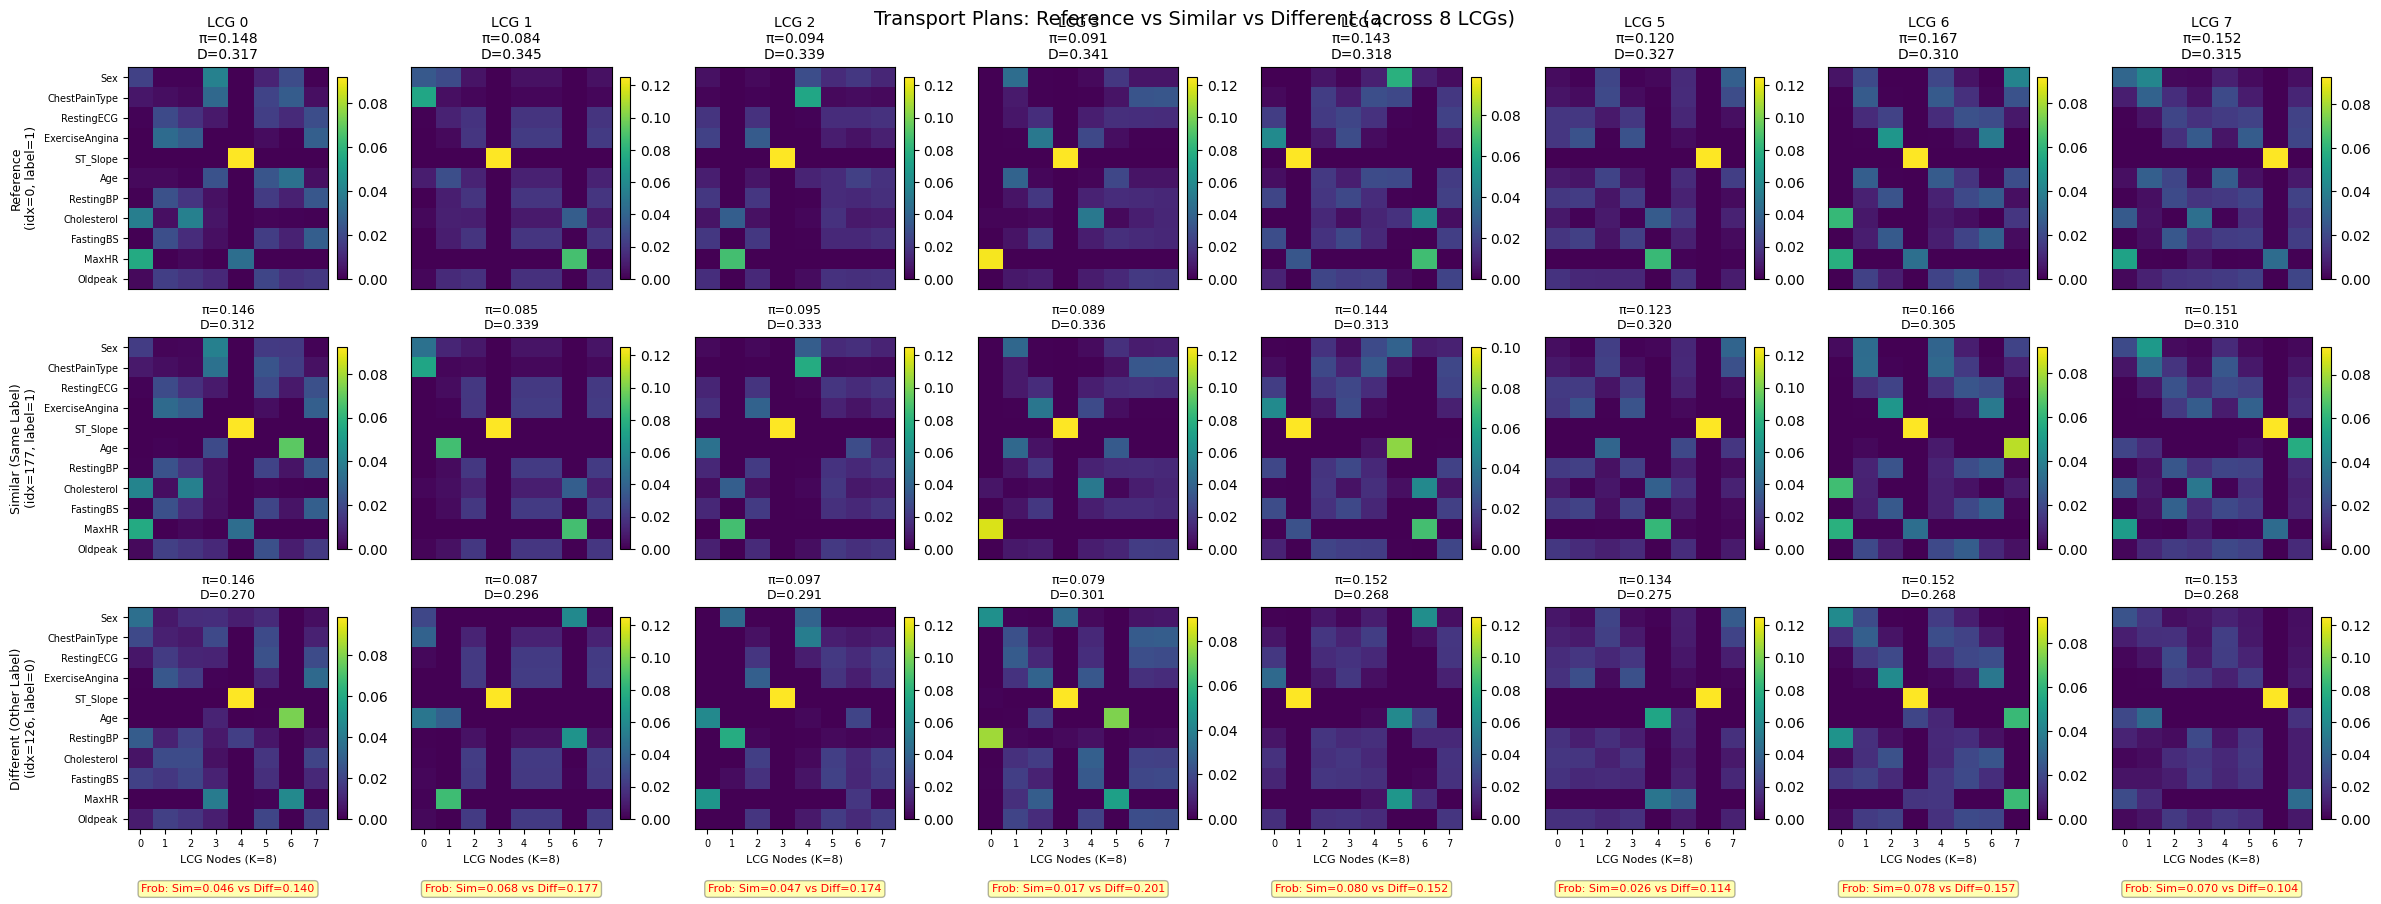

In [78]:
# Transport Plans 계산
print("\nComputing transport plans...")
target_sample_indices = [target_ref_idx, target_sim_idx, target_diff_idx]

target_plans, target_distances, target_coordinates = compute_transport_plans_for_samples(
    target_rr_model, target_sample_indices, target_embeddings, target_affinities
)

print("\n=== Target Pi (Coordinates) ===")
print("Reference:", target_coordinates[0])
print("Similar:", target_coordinates[1])
print("Different:", target_coordinates[2])
# Transport Plans 시각화
plot_transport_plans_grid(
    target_plans, target_coordinates, target_distances,
    target_sample_indices, target_labels, target_feature_names[0]
)

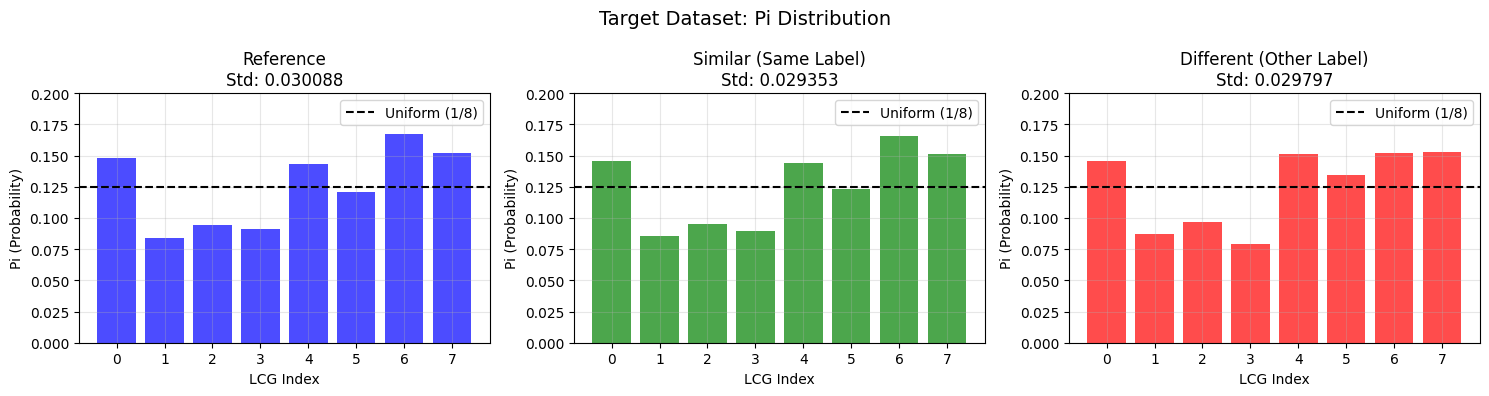

In [79]:
# Pi 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
colors = ['blue', 'green', 'red']

for i, (coord, name, color) in enumerate(zip(target_coordinates, sample_names, colors)):
    ax = axes[i]
    ax.bar(range(8), coord, color=color, alpha=0.7)
    ax.set_xlabel('LCG Index')
    ax.set_ylabel('Pi (Probability)')
    ax.set_title(f'{name}\nStd: {coord.std():.6f}')
    ax.set_ylim([0, max(0.2, coord.max() * 1.1)])
    ax.axhline(y=1/8, color='black', linestyle='--', label='Uniform (1/8)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Target Dataset: Pi Distribution', fontsize=14)
plt.tight_layout()
plt.show()

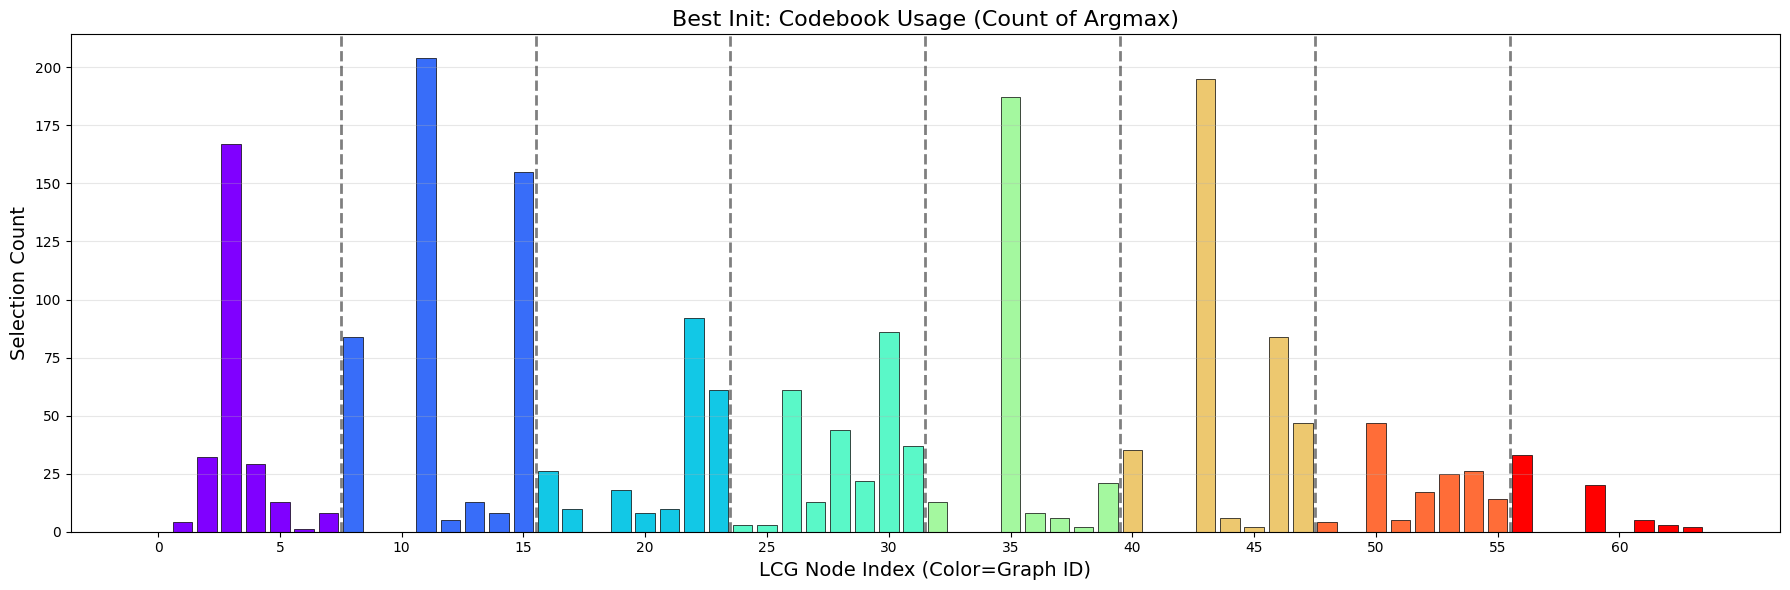


=== Codebook Usage Statistics (Argmax) ===
Total assignments: 2024
LCG 0:   254 (12.5%)
  → Most used node: 3 (167 times)
LCG 1:   469 (23.2%)
  → Most used node: 3 (204 times)
LCG 2:   225 (11.1%)
  → Most used node: 6 (92 times)
LCG 3:   269 (13.3%)
  → Most used node: 6 (86 times)
LCG 4:   237 (11.7%)
  → Most used node: 3 (187 times)
LCG 5:   369 (18.2%)
  → Most used node: 3 (195 times)
LCG 6:   138 (6.8%)
  → Most used node: 2 (47 times)
LCG 7:    63 (3.1%)
  → Most used node: 0 (33 times)


In [80]:
# Codebook Usage (Argmax)
print("\nCollecting codebook usage for target...")
target_assignments, target_source_labels = collect_all_source_assignments(
    target_rr_model, {target_args.target_data: target_loader}, 
    [target_args.target_data], device
)

plot_codebook_usage_argmax(
    target_assignments, target_source_labels, 
    [target_args.target_data], M=8, K=8
)

In [36]:
@torch.no_grad()
def collect_all_cls_embeddings(model, loaders, device):
    """
    모든 loader의 CLS embeddings 수집
    
    Returns:
        cls_embeddings: [N_total, D] - 모든 CLS embeddings
    """
    all_cls_tokens = []
    model.eval()
    
    for src_name, loader in loaders.items():
        print(f"   - Collecting CLS from: {src_name}")
        for batch in loader:
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) 
                    for k, v in batch.items()}
            
            # name/value embeddings
            name_embs, val_embs = [], []
            if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
            if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
            if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
            if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
            
            if not name_embs: continue
            
            name = torch.cat(name_embs, dim=1)
            val = torch.cat(val_embs, dim=1)
            
            # CLS + value
            x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
            
            # GAT forward
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x_basis)
                basis_outputs, _ = model.basis_layers[l](name, norm_x)
                x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
            
            # CLS token
            cls_token = x_basis[:, 0, :].cpu().numpy()
            all_cls_tokens.append(cls_token)
    
    return np.concatenate(all_cls_tokens, axis=0)